# ARTIX

## plots

In [ ]:
import pickle

with open(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\pickle datasets\artix.pickle", "rb") as f:
    patients = pickle.load(f)

print(len(patients))

In [ ]:
import pandas
import plotly.express as px
import numpy as np

map_names = {
    'PAROH_DOSE': ("ipsilateral", "parotid"),
    'PAROC_DOSE': ("contralateral", "parotid"),
    'SMAXH_DOSE': ("ipsilateral", "submandibular"),
    'SMAXC_DOSE': ("contralateral", "submandibular"),
    'MOUTH_DOSE': ("both", "mouth"),
 }

df = []
for p in patients:
    for k, v in p.clinical.items():
        if (not k in map_names.keys()) or (isinstance(v, str) and not is_float_try(v)):
            continue

        side, oar = map_names[k]
        df.append({"id": p.id, "arm": p.clinical["arm"], "side": side, "oar": oar, "dose": float(v)})
        
df = pandas.DataFrame(df)
print(df)

fig = px.box(df, x="arm", y="dose", color="side", facet_col="oar")
fig.show()

In [ ]:
import pandas

def fn(x):
    if isinstance(x, str) and x.isdigit():
        return int(x)
    else:
        return None

df = []
for p in patients:
    for cm in p.clinical_measurements:
        df.append({"id": p.id, **cm})

df = pandas.DataFrame(df)
print(df)

print(df["type"].unique())

idx = (df["type"] == "SSF") & (df["visitID"] == 'Inclusion')
dff = df[idx]
dff["value"] = dff["value"].apply(fn)

print("total: ", len(dff))
print("xersotomia baseline unknown: ", len(dff[dff["value"].isna()]))
print("xerostomia baseline positive: ", len(dff[dff["value"] < 500]))
print("xersotomia baseline negative: ", len(dff[dff["value"] >= 500]))

In [ ]:
import plotly.express as px

dff = df[df["type"] == "SSF"]
dff["value"] = dff["value"].apply(fn)

# exclude basline xerostomia
inclusion_idx =  (dff["visitID"] == "Inclusion")
noxerobaseline_idx = (dff[inclusion_idx]["value"].notna()) & (dff[inclusion_idx]["value"] >= 500)
dff = dff[dff["id"].isin(dff[inclusion_idx][noxerobaseline_idx]["id"].unique())]

print(len(dff))
fig = px.line(dff, x='visitID', y='value', color='id', title="SSF(t)")
fig.add_hline(y=500, line_dash="dot")
fig.update_layout(height=400, width=800)
fig.show()

In [ ]:
import plotly.express as px

dff = df[df["type"] == "SSF"]
dff["value"] = dff["value"].apply(fn)

# exclude basline xerostomia
inclusion_idx =  (dff["visitID"] == "Inclusion")
noxerobaseline_idx = (dff[inclusion_idx]["value"].notna()) & (dff[inclusion_idx]["value"] >= 500)
dff = dff[dff["id"].isin(dff[inclusion_idx][noxerobaseline_idx]["id"].unique())]

no_xero_id = [id_ for id_ in dff["id"].unique() if len(dff[(dff["id"] == id_) & (dff["value"] < 500)]) == 0]
xero_id = [id_ for id_ in dff["id"].unique() if not(id_) in no_xero_id]

xero_df = dff[df["id"].isin(xero_id)]
print(len(xero_id))
fig = px.line(xero_df, x='visitID', y='value', color='id', title="SSF(t) for patients with xerostomia")
fig.add_hline(y=500, line_dash="dot")
fig.update_layout(height=400, width=800)
fig.show()

no_xero_df = dff[df["id"].isin(no_xero_id)]
print(len(no_xero_id))
fig = px.line(no_xero_df, x='visitID', y='value', color='id', title="SSF(t) for patients without xerostomia at any point in time")
fig.add_hline(y=500, line_dash="dot")
fig.update_layout(height=400, width=800)
fig.show()

In [ ]:
import plotly.express as px

def fn(x):
    if isinstance(x, str) and x.isdigit():
        return int(x)
    else:
        return None

dff = df[df["type"] == "SSF"]
dff["value"] = dff["value"].apply(fn)

fig = px.histogram(dff, x="value", facet_row ="visitID")
fig.add_vline(x=500, line_dash="dot")
fig.update_layout(height=1000)
fig.show()

In [ ]:
import plotly.express as px

def fn(x):
    if isinstance(x, str) and x.isdigit():
        return int(x)
    else:
        return None

dff = df[(df["type"] == "MDA") & (df["sample"] == "Q10")]
dff["value"] = dff["value"].apply(fn)

fig = px.histogram(dff, x="value", facet_row ="visitID")
fig.update_layout(height=1200)
fig.show()

In [ ]:
import re

def transform_SSF(x):
    if isinstance(x, str) and x.isdigit():
        return int(x)
    else:
        return None
    
def transform_MDA(x):
    return transform_SSF(x)
    
def transform_AE(x):
    if isinstance(x, str):
        digits = re.findall("\d", x)
        if len(digits) == 0:
            return None
        else:
            return int(digits[0])
    else:
        return None


# select xerostomia CTCAE and MDA
dff = df[((df["type"] == "MDA") & (df["sample"] == "Q10")) | ((df["type"] == "AE") & (df["sample"] == "XEROSTOMIE")) | (df["type"] == "SSF")]

# transform values

SSF_idx = (dff["type"] == "SSF")
dff.loc[SSF_idx, "value"] = dff[SSF_idx]["value"].apply(transform_SSF)

MDA_idx = (dff["type"] == "MDA")
dff.loc[MDA_idx,"value"] = dff[MDA_idx]["value"].apply(transform_MDA)

AE_idx = (dff["type"] == "AE")
dff.loc[AE_idx,"value"] = dff[AE_idx]["value"].apply(transform_AE)

# change AE visitID=S0 into Inclusion
dff.loc[(dff["type"] == "AE") & (dff["visitID"] == "S0"), "visitID"] = "Inclusion"

In [ ]:
t1, t2 = "AE", "MDA"

x = sorted(dff[dff["type"] == t1]["value"].dropna().unique())
y = sorted(dff[dff["type"] == t2]["value"].dropna().unique())

data = []
for xx in x:
    counts = []
    for yy in y:
        counts.append(0)
        for visit in dff["visitID"].unique():
            for id in dff["id"].unique():
                sub_dff = dff[(dff["type"].isin([t1, t2])) & (dff["visitID"] == visit) & (dff["id"] == id)]
                try:
                    if sub_dff[sub_dff["type"] == t1]["value"].item() == xx and sub_dff[sub_dff["type"] == t2]["value"].item() == yy:
                        counts[-1] = counts[-1] + 1 
                except ValueError:
                    continue
    data.append(counts)

fig = px.imshow(data,
                labels=dict(x=t2, y=t1),
                x=list(map(str, y)),
                y=list(map(str, x)),
                    text_auto=True
            )
fig.show()

In [ ]:
sub_dff = []
for visit in dff["visitID"].unique():
    for id in dff["id"].unique():
        sub_dff.append({})
        for t in dff["type"].unique():
            try:
                sub_dff[-1].update({t: dff[(dff["type"] == t) & (dff["visitID"] == visit) & (dff["id"] == id)]["value"].item()})
            except ValueError:
                sub_dff[-1].update({t: None})

sub_dff = pandas.DataFrame(sub_dff)

fig = px.histogram(sub_dff, x="SSF", facet_row ="AE", marginal='violon')
fig.update_layout(height=1000)
fig.show()

sub_dff.loc[sub_dff["MDA"].isin([0,1,2]), "MDA"] = 1
sub_dff.loc[sub_dff["MDA"].isin([3,4,5]), "MDA"] = 2
sub_dff.loc[sub_dff["MDA"].isin([6,7,8]), "MDA"] = 3
sub_dff.loc[sub_dff["MDA"].isin([9]), "MDA"] = 4
fig = px.histogram(sub_dff, x="SSF", facet_row ="MDA", marginal='violon')
fig.update_layout(height=1000)
fig.show()

In [ ]:
import plotly.express as px
from scipy.stats import f_oneway, spearmanr
import pandas
import pickle
import re

def transform_SSF(x):
    if isinstance(x, str) and x.isdigit():
        return int(x)
    else:
        return None
    
def transform_MDA(x):
    return transform_SSF(x)
    
def transform_AE(x):
    if isinstance(x, str):
        digits = re.findall("\d", x)
        if len(digits) == 0:
            return None
        else:
            return int(digits[0])
    else:
        return None


# select xerostomia CTCAE and MDA
dff = df[((df["type"] == "MDA") & (df["sample"] == "Q10")) | ((df["type"] == "AE") & (df["sample"] == "XEROSTOMIE")) | (df["type"] == "SSF")]

# transform values

SSF_idx = (dff["type"] == "SSF")
dff.loc[SSF_idx, "value"] = dff[SSF_idx]["value"].apply(transform_SSF)

MDA_idx = (dff["type"] == "MDA")
dff.loc[MDA_idx,"value"] = dff[MDA_idx]["value"].apply(transform_MDA)

AE_idx = (dff["type"] == "AE")
dff.loc[AE_idx,"value"] = dff[AE_idx]["value"].apply(transform_AE)

# change AE visitID=S0 into Inclusion
dff.loc[(dff["type"] == "AE") & (dff["visitID"] == "S0"), "visitID"] = "Inclusion"

sub_dff = []
for visit in dff["visitID"].unique():
    for id in dff["id"].unique():
        sub_dff.append({})
        for t in dff["type"].unique():
            try:
                sub_dff[-1].update({t: dff[(dff["type"] == t) & (dff["visitID"] == visit) & (dff["id"] == id)]["value"].item()})
            except ValueError:
                sub_dff[-1].update({t: None})

sub_dff = pandas.DataFrame(sub_dff)

sub_dff_bis = sub_dff[(sub_dff["SSF"].notna()) & (sub_dff["AE"].notna())]
groups = [sub_dff_bis[sub_dff_bis["AE"] == i]["SSF"].to_numpy() for i in sub_dff_bis["AE"].unique()]
print(len(groups))
print(f_oneway(*groups))
print(spearmanr(sub_dff_bis["SSF"].to_numpy(), sub_dff_bis["AE"].to_numpy()))

sub_dff_bis = sub_dff[(sub_dff["SSF"].notna()) & (sub_dff["MDA"].notna())]
# sub_dff_bis.loc[sub_dff["MDA"].isin([0,1,2,3,4]), "MDA"] = 1
# sub_dff_bis.loc[sub_dff["MDA"].isin([5,6]), "MDA"] = 2
# sub_dff_bis.loc[sub_dff["MDA"].isin([7,8,9,10]), "MDA"] = 3
groups = [sub_dff_bis[sub_dff_bis["MDA"] == i]["SSF"].to_numpy() for i in sub_dff_bis["MDA"].unique()]
print()
print(len(groups))
print(f_oneway(*groups))
print(spearmanr(sub_dff_bis["SSF"].to_numpy(), sub_dff_bis["MDA"].to_numpy()))

print()
sub_dff_bis = sub_dff[(sub_dff["AE"].notna()) & (sub_dff["MDA"].notna())]
print(spearmanr(sub_dff_bis["MDA"].to_numpy(), sub_dff_bis["AE"].to_numpy()))

# group MDA into smaller groups
sub_dff.loc[sub_dff["MDA"].isin([0,1,2]), "MDA"] = 1
sub_dff.loc[sub_dff["MDA"].isin([3,4,5]), "MDA"] = 2
sub_dff.loc[sub_dff["MDA"].isin([6,7,8]), "MDA"] = 3
sub_dff.loc[sub_dff["MDA"].isin([9, 10]), "MDA"] = 4
fig = px.box(sub_dff, x="MDA", y="SSF")
fig.update_layout(height=600, width=800)
fig.show()

fig = px.box(sub_dff, x="AE", y="SSF")
fig.update_layout(height=600, width=800)
fig.show()

sub_dff_bis = pandas.DataFrame()
for k1 in sub_dff["AE"].dropna().unique():
    for k2 in sub_dff["MDA"].dropna().unique():
        sub_dff_bis.loc[k1, k2] = len(sub_dff[(sub_dff["AE"] == k1) & (sub_dff["MDA"] == k2)])

sub_dff_bis = sub_dff_bis.sort_index().reindex(sorted(sub_dff_bis.columns), axis=1)

fig = px.imshow(sub_dff_bis, text_auto=True)
fig.update_layout(height=600, width=800)
fig.update_layout(xaxis_title=dict(text='MDA'), yaxis_title=dict(text='CTCAE'))
fig.show()

# # group MDA into smaller groups
# sub_dff.loc[sub_dff["MDA"].isin([0,1,2]), "MDA"] = 1
# sub_dff.loc[sub_dff["MDA"].isin([3,4,5]), "MDA"] = 2
# sub_dff.loc[sub_dff["MDA"].isin([6,7,8]), "MDA"] = 3
# sub_dff.loc[sub_dff["MDA"].isin([9, 10]), "MDA"] = 4
# print(spearmanr(sub_dff["MDA"].to_numpy(), sub_dff["AE"].to_numpy()))

sub_dff_bis = pandas.DataFrame()
for k1 in sub_dff["AE"].dropna().unique():
    for k2 in sub_dff["MDA"].dropna().unique():
        sub_dff_bis.loc[k1, k2] = len(sub_dff[(sub_dff["AE"] == k1) & (sub_dff["MDA"] == k2)])

sub_dff_bis = sub_dff_bis.sort_index().reindex(sorted(sub_dff_bis.columns), axis=1)

fig = px.imshow(sub_dff_bis, text_auto=True)
fig.update_layout(height=600, width=800)
fig.update_layout(xaxis_title=dict(text='MDA'), yaxis_title=dict(text='CTCAE'))
fig.show()

In [ ]:
from scipy.stats import spearmanr
import plotly.express as px
import pandas
import pickle
import re

    
def transform_MDA(x):
    if isinstance(x, str) and x.isdigit():
        return int(x)
    else:
        return None
    
def transform_AE(x):
    if isinstance(x, str):
        digits = re.findall("\d", x)
        if len(digits) == 0:
            return None
        else:
            return int(digits[0])
    else:
        return None

with open(r"C:\Users\bilel.guetarni\Desktop\tmp\artix.pkl", "rb") as f:
    patients = pickle.load(f)


df = []
for p in patients:
    for cm in p.clinical_measurements:
        df.append({"id": p.id, **cm})

df = pandas.DataFrame(df)

# select dysphagia CTCAE and MDA
dff = df[((df["type"] == "MDA") & (df["sample"] == "Q10")) | ((df["type"] == "AE") & (df["sample"] == "XEROSTOMIE"))]

# transform values
MDA_idx = (dff["type"] == "MDA")
dff.loc[MDA_idx,"value"] = dff[MDA_idx]["value"].apply(transform_MDA)

AE_idx = (dff["type"] == "AE")
dff.loc[AE_idx,"value"] = dff[AE_idx]["value"].apply(transform_AE)

# change AE visitID=S0 into Inclusion
dff.loc[(dff["type"] == "AE") & (dff["visitID"] == "S0"), "visitID"] = "Inclusion"

sub_dff = []
for visit in dff["visitID"].unique():
    for id in dff["id"].unique():
        sub_dff.append({})
        for t in dff["type"].unique():
            try:
                sub_dff[-1].update({t: dff[(dff["type"] == t) & (dff["visitID"] == visit) & (dff["id"] == id)]["value"].item()})
            except ValueError:
                sub_dff[-1].update({t: None})

sub_dff = pandas.DataFrame(sub_dff)
sub_dff_bis = sub_dff[(sub_dff["AE"].notna()) & (sub_dff["MDA"].notna())]
print(spearmanr(sub_dff_bis["MDA"].to_numpy(), sub_dff_bis["AE"].to_numpy()))


sub_dff_bis = pandas.DataFrame()
for k1 in sub_dff["AE"].dropna().unique():
    for k2 in sub_dff["MDA"].dropna().unique():
        sub_dff_bis.loc[k1, k2] = len(sub_dff[(sub_dff["AE"] == k1) & (sub_dff["MDA"] == k2)])

sub_dff_bis = sub_dff_bis.sort_index().reindex(sorted(sub_dff_bis.columns), axis=1)

# print(sub_dff_bis)
fig = px.imshow(sub_dff_bis, text_auto=True, title="XEROSTOMIE")
fig.update_layout(xaxis_title=dict(text='MDA'), yaxis_title=dict(text='CTCAE'))
fig.show()

# group MDA into smaller groups
sub_dff.loc[sub_dff["MDA"].isin([0,1,2,3,4]), "MDA"] = 1
sub_dff.loc[sub_dff["MDA"].isin([5,6,7]), "MDA"] = 2
sub_dff.loc[sub_dff["MDA"].isin([8,9,10]), "MDA"] = 3

sub_dff_bis = sub_dff[(sub_dff["AE"].notna()) & (sub_dff["MDA"].notna())]
print(spearmanr(sub_dff_bis["MDA"].to_numpy(), sub_dff_bis["AE"].to_numpy()))

# gather sample points
sub_dff_bis = pandas.DataFrame()
for k1 in sub_dff["AE"].dropna().unique():
    for k2 in sub_dff["MDA"].dropna().unique():
        sub_dff_bis.loc[k1, k2] = len(sub_dff[(sub_dff["AE"] == k1) & (sub_dff["MDA"] == k2)])

sub_dff_bis = sub_dff_bis.sort_index().reindex(sorted(sub_dff_bis.columns), axis=1)
fig = px.imshow(sub_dff_bis, text_auto=True, title="XEROSTOMIE")
fig.update_layout(xaxis_title=dict(text='MDA'), yaxis_title=dict(text='CTCAE'))
fig.show()

In [ ]:
from scipy.stats import spearmanr
import plotly.express as px
import pandas
import pickle
import re

    
def transform_MDA(x):
    if isinstance(x, str) and x.isdigit():
        return int(x)
    else:
        return None
    
def transform_AE(x):
    if isinstance(x, str):
        digits = re.findall("\d", x)
        if len(digits) == 0:
            return None
        else:
            return int(digits[0])
    else:
        return None

with open(r"C:\Users\bilel.guetarni\Desktop\tmp\artix.pkl", "rb") as f:
    patients = pickle.load(f)


df = []
for p in patients:
    for cm in p.clinical_measurements:
        df.append({"id": p.id, **cm})

df = pandas.DataFrame(df)

# select dysphagia CTCAE and MDA
dff = df[((df["type"] == "MDA") & (df["sample"] == "Q15")) | ((df["type"] == "AE") & (df["sample"] == "DYSPHAGIE"))]

# transform values
MDA_idx = (dff["type"] == "MDA")
dff.loc[MDA_idx,"value"] = dff[MDA_idx]["value"].apply(transform_MDA)

AE_idx = (dff["type"] == "AE")
dff.loc[AE_idx,"value"] = dff[AE_idx]["value"].apply(transform_AE)

# change AE visitID=S0 into Inclusion
dff.loc[(dff["type"] == "AE") & (dff["visitID"] == "S0"), "visitID"] = "Inclusion"

sub_dff = []
for visit in dff["visitID"].unique():
    for id in dff["id"].unique():
        sub_dff.append({})
        for t in dff["type"].unique():
            try:
                sub_dff[-1].update({t: dff[(dff["type"] == t) & (dff["visitID"] == visit) & (dff["id"] == id)]["value"].item()})
            except ValueError:
                sub_dff[-1].update({t: None})

sub_dff = pandas.DataFrame(sub_dff)
sub_dff_bis = sub_dff[(sub_dff["AE"].notna()) & (sub_dff["MDA"].notna())]
print(spearmanr(sub_dff_bis["MDA"].to_numpy(), sub_dff_bis["AE"].to_numpy()))


sub_dff_bis = pandas.DataFrame()
for k1 in sub_dff["AE"].dropna().unique():
    for k2 in sub_dff["MDA"].dropna().unique():
        sub_dff_bis.loc[k1, k2] = len(sub_dff[(sub_dff["AE"] == k1) & (sub_dff["MDA"] == k2)])

sub_dff_bis = sub_dff_bis.sort_index().reindex(sorted(sub_dff_bis.columns), axis=1)

# print(sub_dff_bis)
fig = px.imshow(sub_dff_bis, text_auto=True, title="DYSPHAGIE")
fig.update_layout(xaxis_title=dict(text='MDA'), yaxis_title=dict(text='CTCAE'))
fig.show()

# group MDA into smaller groups
sub_dff.loc[sub_dff["MDA"].isin([0,1,2,3,4]), "MDA"] = 1
sub_dff.loc[sub_dff["MDA"].isin([5,6,7]), "MDA"] = 2
sub_dff.loc[sub_dff["MDA"].isin([8,9,10]), "MDA"] = 3

sub_dff_bis = sub_dff[(sub_dff["AE"].notna()) & (sub_dff["MDA"].notna())]
print(spearmanr(sub_dff_bis["MDA"].to_numpy(), sub_dff_bis["AE"].to_numpy()))

# gather sample points
sub_dff_bis = pandas.DataFrame()
for k1 in sub_dff["AE"].dropna().unique():
    for k2 in sub_dff["MDA"].dropna().unique():
        sub_dff_bis.loc[k1, k2] = len(sub_dff[(sub_dff["AE"] == k1) & (sub_dff["MDA"] == k2)])

sub_dff_bis = sub_dff_bis.sort_index().reindex(sorted(sub_dff_bis.columns), axis=1)
fig = px.imshow(sub_dff_bis, text_auto=True, title="DYSPHAGIE")
fig.update_layout(xaxis_title=dict(text='MDA'), yaxis_title=dict(text='CTCAE'))
fig.show()

In [ ]:
import plotly.express as px
import pandas
import pickle
import re

    
def transform_SSF(x):
    if isinstance(x, str) and x.isdigit():
        return int(x)
    else:
        return None
    
def transform_MDA(x):
    return transform_SSF(x)
    
def transform_AE(x):
    if isinstance(x, str):
        digits = re.findall("\d", x)
        if len(digits) == 0:
            return None
        else:
            return int(digits[0])
    else:
        return None

with open(r"C:\Users\bilel.guetarni\Desktop\tmp\artix.pkl", "rb") as f:
    patients = pickle.load(f)


df = []
for p in patients:
    for cm in p.clinical_measurements:
        df.append({"id": p.id, **cm})

df = pandas.DataFrame(df)

# select dysphagia CTCAE and MDA
dff = df[((df["type"] == "MDA") & (df["sample"] == "Q10")) | ((df["type"] == "AE") & (df["sample"] == "XEROSTOMIE")) | (df["type"] == "SSF")]

# transform values

SSF_idx = (dff["type"] == "SSF")
dff.loc[SSF_idx, "value"] = dff[SSF_idx]["value"].apply(transform_SSF)

MDA_idx = (dff["type"] == "MDA")
dff.loc[MDA_idx,"value"] = dff[MDA_idx]["value"].apply(transform_MDA)

AE_idx = (dff["type"] == "AE")
dff.loc[AE_idx,"value"] = dff[AE_idx]["value"].apply(transform_AE)

# change AE visitID=S0 into Inclusion
dff.loc[(dff["type"] == "AE") & (dff["visitID"] == "S0"), "visitID"] = "Inclusion"

data = []
for visit in dff["visitID"].unique():
    for id in dff["id"].unique():
        sub_dff = dff[(dff["visitID"] == visit) & (dff["id"] == id)]
        try:
            if sub_dff[sub_dff["type"] == "AE"]["value"].notna().item() and sub_dff[sub_dff["type"] == "MDA"]["value"].notna().item() and sub_dff[sub_dff["type"] == "SSF"]["value"].notna().item():
                data.append({"AE": sub_dff[sub_dff["type"] == "AE"]["value"].item(), "MDA": sub_dff[sub_dff["type"] == "MDA"]["value"].item(), "SSF": sub_dff[sub_dff["type"] == "SSF"]["value"].item()})
        except ValueError:
            continue

sub_dff = pandas.DataFrame(data)
print(sub_dff)

# sub_dff.loc[sub_dff["MDA"].isin([0,1]), "MDA"] = 1
# sub_dff.loc[sub_dff["MDA"].isin([2,3,4]), "MDA"] = 2
# sub_dff.loc[sub_dff["MDA"].isin([5,6,7]), "MDA"] = 3
# sub_dff.loc[sub_dff["MDA"].isin([8,9,10]), "MDA"] = 4

# sub_dff.loc[sub_dff["MDA"].isin([0,1,2]), "MDA"] = 1
# sub_dff.loc[sub_dff["MDA"].isin([3,4,5,6,7]), "MDA"] = 2
# sub_dff.loc[sub_dff["MDA"].isin([8,9,10]), "MDA"] = 3


# data = []
# for i in sub_dff["MDA"].unique():
#     for j in sub_dff["AE"].unique():
#         ssf_ = sub_dff[(sub_dff["MDA"] == i) & (sub_dff["AE"] == j)]["SSF"]
#         data.append({"MDA": i, "AE": j, "mean": ssf_.mean(), "std": ssf_.std(ddof=0), "N": len(ssf_)})

# sub_dff = pandas.DataFrame(data)
# print(sub_dff)

In [ ]:
from sklearn.linear_model import LinearRegression
X, y = np.array(list(zip(sub_dff["MDA"].to_numpy(), sub_dff["AE"].to_numpy()))), sub_dff["SSF"].to_numpy() / sub_dff["SSF"].max()
clf = LinearRegression().fit(X, y)
print(clf.score(X,y))

In [ ]:
import pandas
import datetime
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def convert2date(dt):
    return datetime.datetime.strptime(dt, "%d/%m/%Y").date()

def plot_recc_data(data):
    rfs2y = []
    for i in data:
        dt, cens = i["dt"], i["censored"]
        if not(cens):
            if dt < 2*365:
                rfs2y.append({"y": "yes", "year": 2})
                rfs2y.append({"y": "yes", "year": 5})
            elif 2*365 < dt and dt < 5*365:
                rfs2y.append({"y": "no", "year": 2})
                rfs2y.append({"y": "yes", "year": 5})
            else:
                rfs2y.append({"y": "no", "year": 2})
                rfs2y.append({"y": "no", "year": 5})
        else:
            if dt > 2*365:
                rfs2y.append({"y": "no", "year": 2})
            if dt > 5*365:
                rfs2y.append({"y": "no", "year": 5})
    rfs2y = pandas.DataFrame(rfs2y)

    fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]])
    for c, year in enumerate(rfs2y["year"].unique()):
        df = rfs2y[rfs2y["year"] == year]
        print(len(df))
        labels = df["y"].unique()
        values = [len(df[df["y"] == i]) for i in labels]
        fig.add_trace(go.Pie(labels=labels, values=values, title=f"{year} years"), 1, c+1)
    
    fig.update_layout(autosize=False, width=800, height=400)
    fig.show()

efficacy = pandas.read_csv(r"E:\bilel\ARTIX\ARTIX\toxicity_data\20241021_EFFICACY_LTSI.csv", sep=";")
treatment = pandas.read_csv(r"E:\bilel\ARTIX\ARTIX\toxicity_data\20241021_TREATMENT_LTSI.csv", sep=";")

data = []
for _, row in efficacy.iterrows():
    try:
        rtend = treatment[treatment["USUBJID"] == row["USUBJID"]]["RTENDT"].iloc[0]
        if pandas.isna(row["PROGDT"]) or pandas.isna(rtend):
            prog_endrt_days = None
        else:
            prog_endrt_days = (convert2date(row["PROGDT"]) - convert2date(rtend)).days

        if row["DDNDT"] is None or pandas.isna(rtend):
            endfollow_endrt_days = None
        else:
            endfollow_endrt_days = (convert2date(row["DDNDT"]) - convert2date(rtend)).days
        
        if row["PROG"] == "Yes":
            if prog_endrt_days is None:
                continue
            else:
                data.append({"dt": prog_endrt_days, "censored": False})
        elif not(endfollow_endrt_days is None):
            data.append({"dt": endfollow_endrt_days, "censored": True})
        else:
            continue
    except (KeyError, TypeError):
        continue

# print(len(data))
plot_recc_data(data)

## features

In [ ]:
import pandas
import pickle
import re
    
def transform_AE(x):
    if isinstance(x, str):
        digits = re.findall("\d", x)
        if len(digits) == 0:
            return None
        else:
            return int(digits[0])
    else:
        return None
    
# timestamps = ['M6', 'M12', 'M18', 'M24']
timestamps = ['M6']

df = []
with open(r"C:\Users\bilel.guetarni\Desktop\tmp\artix.pkl", "rb") as f:
    patients = pickle.load(f)
    for p in patients:
        for cm in p.clinical_measurements:
            df.append({"id": p.id, **cm})
df = pandas.DataFrame(df)

# select dysphagia and xerostomia in CTCAE
df = df[(df["type"] == "AE") & ((df["sample"] == "XEROSTOMIE") | (df["sample"] == "DYSPHAGIE"))]

# transform values
df.loc[(df["type"] == "AE"),"value"] = df[(df["type"] == "AE")]["value"].apply(transform_AE)

# change S0 into Inclusion
df.loc[(df["type"] == "AE") & (df["visitID"] == "S0"), "visitID"] = "Inclusion"

# keep only timestamps
df = df[df["visitID"].isin(timestamps)]
print(df)

In [ ]:
import plotly.express as px

for s in df["sample"].unique():
    print(s)
    dff = df[df["sample"] == s]
    for epoc in df["visitID"].unique():
        print(epoc)
        sub_df = dff[dff["visitID"] == epoc]
        # for i in sub_df["value"].unique():
        #     if pandas.isna(i):
        #         n = len(sub_df[sub_df["value"].isna()])
        #         print(f"{i}: {n} ({int(100 * n / len(sub_df))}%)")
        #     else:
        #         n = len(sub_df[sub_df["value"] == i])
        #         print(f"{i}: {n} ({int(100 * n / len(sub_df))}%)")

        fig = px.histogram(sub_df, x="value")
        fig.update_layout(bargap=0.2)
        fig.show()

### DVH

In [ ]:
from dicompylercore import dvhcalc, dicomparser

p = patients[0]
p.sort_imaging()
ct = p.ct[0]
print(p.ct[0].get_acquisition_date())
print(ct.get_dcm_path())
print(ct.rtdose.get_dcm_path())
print(ct.rtstruct.get_dcm_path())

dvh_features = dict()
for _, struct_info in list(dicomparser.DicomParser(ct.rtstruct.get_dcm_path()).GetStructures().items())[8:10]:
    calcdvh = dvhcalc.get_dvh(ct.rtstruct.get_dcm_path(), ct.rtdose.get_dcm_path(), struct_info["id"])
    calcdvh.rx_dose = 70
    calcdvh = calcdvh.relative_volume # transform into relative volume DVH
    calcdvh = calcdvh.absolute_dose()
    dvh_features.update({struct_info["name"]: {
        "mean": calcdvh.mean,
        "min": calcdvh.min,
        "max": calcdvh.max,
        "D98": calcdvh.dose_constraint(98, volume_units='%'),
        **{f"D{v}": calcdvh.dose_constraint(v, volume_units='%') for v in range(10,100,10)},
        **{f"V{d}": calcdvh.volume_constraint(d, dose_units='Gy') for d in range(5,80,5)},
    }})

In [ ]:
dvh_features

In [ ]:
from rt_utils import RTStructBuilder
import numpy as np
import SimpleITK as sitk
from dicompylercore import dvhcalc, dicomparser

new_name = "new-stucture"

# Create new RT Struct. Requires the DICOM series path for the RT Struct.
rtstruct = RTStructBuilder.create_new(dicom_series_path=r"C:\Users\bilel.guetarni\Desktop\data\ARTIX\DICOM_ARTIX_data\019\CT0\DOE^JOHN_ANON15009_CT_2014-04-02_110230_ORL.(sauf.sinus)_ORL.2MM_n197__00000")

# Add the 3D mask as an ROI.
# The colour, description, and name will be auto generated
MASK_FROM_ML_MODEL = sitk.ReadImage(r"C:\Users\bilel.guetarni\Desktop\tmp\mask.nii.gz")
MASK_FROM_ML_MODEL = sitk.GetArrayFromImage(MASK_FROM_ML_MODEL)
print(np.unique(MASK_FROM_ML_MODEL))
MASK_FROM_ML_MODEL[MASK_FROM_ML_MODEL != 3] = 0
MASK_FROM_ML_MODEL[MASK_FROM_ML_MODEL == 3] = 1
print(np.unique(MASK_FROM_ML_MODEL))
MASK_FROM_ML_MODEL = np.moveaxis(MASK_FROM_ML_MODEL.astype("bool"), 0, -1)
MASK_FROM_ML_MODEL = np.flip(MASK_FROM_ML_MODEL, axis=0)
rtstruct.add_roi(mask=MASK_FROM_ML_MODEL, name=new_name)

rtstruct.save(r"C:\Users\bilel.guetarni\Desktop\tmp\mask.dcm")

calcdvh = dvhcalc.get_dvh(r"C:\Users\bilel.guetarni\Desktop\tmp\mask.dcm", 
                          r"C:\Users\bilel.guetarni\Desktop\data\ARTIX\DICOM_ARTIX_data\019\CT0\DOE^JOHN_ANON15009_RTDOSE_2014-04-02_110230_TEP.ORL_CT.0.DOSI.0_n1__00000\2.16.840.1.114362.1.11956109.23961857828.605406546.573.9776.dcm", 
                          {s.ROIName: s.ROINumber for s in rtstruct.ds.StructureSetROISequence}[new_name])
calcdvh.rx_dose = 70
calcdvh = calcdvh.relative_volume # transform into relative volume DVH
calcdvh = calcdvh.absolute_dose()
dvh_features = {
    "mean": calcdvh.mean,
    "min": calcdvh.min,
    "max": calcdvh.max,
    "D98": calcdvh.dose_constraint(98, volume_units='%'),
    **{f"D{v}": calcdvh.dose_constraint(v, volume_units='%') for v in range(10,100,10)},
    **{f"V{d}": calcdvh.volume_constraint(d, dose_units='Gy') for d in range(5,80,5)},
}

# superior_pharyngeal_constrictor
print(dvh_features)

### radiomics

In [ ]:
import SimpleITK as sitk
import pydicom
import numpy as np
import logging
import radiomics
from radiomics import featureextractor
from dicom_utils import fill_vol_ctrs

TMP_CT = r"C:\Users\bilel.guetarni\Desktop\tmp\image.nii.gz"
TMP_MASK = r"C:\Users\bilel.guetarni\Desktop\tmp\mask.nii.gz"
TMP_LOGGING = r"C:\Users\bilel.guetarni\Desktop\tmp\testLog.txt"
PARAM_PATH = r"C:\Users\bilel.guetarni\Desktop\ARTIX\radiomics.yaml"

p = patients[0]
p.sort_imaging()
ct = p.ct[0]
print(p.ct[0].get_acquisition_date())
print(ct.get_dcm_path())
print(ct.rtdose.get_dcm_path())
print(ct.rtstruct.get_dcm_path())

reader = sitk.ImageSeriesReader()
reader.SetFileNames(reader.GetGDCMSeriesFileNames(ct.path))
ct_image = reader.Execute()

rtstruct = pydicom.dcmread(ct.rtstruct.get_dcm_path())
structure_name = ct.rtstruct.get_all_OARs()[8]

roi_index = None
for i, roi in enumerate(rtstruct.StructureSetROISequence):
    if roi.ROIName == structure_name:
        roi_index = roi.ROINumber
        break

# Step 4: Extract contours and convert to mask
contours = []
for item in rtstruct.ROIContourSequence:
    if item.ReferencedROINumber == roi_index:
        for contour in item.ContourSequence:
            contours.append(np.array(contour.ContourData).reshape(-1, 3))
contours = np.concatenate(contours, axis=0)
ctrs = np.array(list(map(ct_image.TransformPhysicalPointToIndex, contours)), dtype=np.int64)
mask = fill_vol_ctrs(sitk.GetArrayFromImage(ct_image).shape, ctrs)

# if z axis is inverted flip mask
if ct_image.GetDirection()[-1] < 0:
    mask = np.flip(mask, axis=0)

mask = sitk.GetImageFromArray(mask.astype(np.uint8))
mask.CopyInformation(ct_image)

sitk.WriteImage(ct_image, TMP_CT)
sitk.WriteImage(mask, TMP_MASK)

# # Get the PyRadiomics logger (default log-level = INFO)
# logger = radiomics.logger
# logger.setLevel(logging.DEBUG)  # set level to DEBUG to include debug log messages in log file

# # Set up the handler to write out all log entries to a file
# handler = logging.FileHandler(filename=TMP_LOGGING, mode="w")
# formatter = logging.Formatter("%(levelname)s:%(name)s: %(message)s")
# handler.setFormatter(formatter)
# logger.addHandler(handler)

# Initialize and run feature extractor
extractor = featureextractor.RadiomicsFeatureExtractor()
extractor.loadParams(PARAM_PATH)
featureVector = extractor.execute(TMP_CT, TMP_MASK)
# featureVector = extractor.execute(TMP_CT, TMP_MASK, label=1, label_channel=0)

In [ ]:
structure_name

In [ ]:
for featureName in featureVector:
    print(f"{featureName}: {featureVector[featureName]}")

In [ ]:
mask = sitk.ReadImage(r"C:\Users\bilel.guetarni\Desktop\ARTIX\data\totalsegmentator\artix\16\DOE^JOHN_ANON15009_CT_2014-04-02_110230_ORL.(sauf.sinus)_ORL.2MM_n197_00000\craniofacial_structures.nii.gz")
arr = sitk.GetArrayFromImage(mask)
print(arr.shape)
print(np.unique(arr))

In [ ]:
from radiomics import featureextractor

PARAM_PATH = r"C:\Users\bilel.guetarni\Desktop\ARTIX\radiomics.yaml"
TMP_CT = r"C:\Users\bilel.guetarni\Desktop\ARTIX\data\nifti\artix\16\DOE^JOHN_ANON15009_CT_2014-04-02_110230_ORL.(sauf.sinus)_ORL.2MM_n197_00000.nii.gz"
# TMP_MASK = r"C:\Users\bilel.guetarni\Desktop\ARTIX\data\totalsegmentator\artix\16\DOE^JOHN_ANON15009_CT_2014-04-02_110230_ORL.(sauf.sinus)_ORL.2MM_n197_00000\craniofacial_structures.nii.gz"
# TMP_MASK = r"C:\Users\bilel.guetarni\Desktop\ARTIX\data\totalsegmentator\artix\16\DOE^JOHN_ANON15009_CT_2014-04-02_110230_ORL.(sauf.sinus)_ORL.2MM_n197_00000\head_glands_cavities.nii.gz"
TMP_MASK = r"C:\Users\bilel.guetarni\Desktop\ARTIX\data\totalsegmentator\artix\16\DOE^JOHN_ANON15009_CT_2014-04-02_110230_ORL.(sauf.sinus)_ORL.2MM_n197_00000\headneck_muscles.nii.gz"

extractor = featureextractor.RadiomicsFeatureExtractor()
extractor.loadParams(PARAM_PATH)
featureVector = extractor.execute(TMP_CT, TMP_MASK, label=5, label_channel=0)

for featureName in featureVector:
    print(f"{featureName}: {featureVector[featureName]}")

In [ ]:
for featureName in featureVector:
    type_, feature_class, feature_name = featureName.split("_")
    print(featureName)
    print("\t ", type_)
    print("\t ", feature_class)
    print("\t ", feature_name)
    print("\t ", featureVector[featureName])

### dosiomics

In [ ]:
import SimpleITK as sitk
import nibabel
import pydicom
import numpy as np
import radiomics
from radiomics import featureextractor
from dicom_utils import fill_vol_ctrs

TMP_CT = r"C:\Users\bilel.guetarni\Desktop\tmp\artix\volume.nii.gz"
TMP_MASK = r"C:\Users\bilel.guetarni\Desktop\tmp\artix\mask.nii.gz"

p = patients[0]
p.sort_imaging()
ct = p.ct[0]
# print(p.ct[0].get_acquisition_date())
print(ct.get_dcm_path())
# print(ct.rtdose.get_dcm_path())
# print(ct.rtstruct.get_dcm_path())

rtdose_image = sitk.ReadImage(ct.rtdose.get_dcm_path())

# apply scaling before computing radiomics !!!!
dose_array = sitk.GetArrayFromImage(rtdose_image).astype("float")
dose_array *= float(pydicom.dcmread(ct.rtdose.get_dcm_path()).DoseGridScaling)
rtdose_image_scaled = sitk.GetImageFromArray(dose_array)
rtdose_image_scaled.CopyInformation(rtdose_image)
rtdose_image = rtdose_image_scaled

rtstruct = pydicom.dcmread(ct.rtstruct.get_dcm_path())
structure_name = ct.rtstruct.get_all_OARs()[15]
print(structure_name)

roi_index = None
for i, roi in enumerate(rtstruct.StructureSetROISequence):
    if roi.ROIName == structure_name:
        roi_index = roi.ROINumber
        break

# Step 4: Extract contours and convert to mask
contours = []
for item in rtstruct.ROIContourSequence:
    if item.ReferencedROINumber == roi_index:
        for contour in item.ContourSequence:
            contours.append(np.array(contour.ContourData).reshape(-1, 3))
contours = np.concatenate(contours, axis=0)
ctrs = np.array(list(map(rtdose_image.TransformPhysicalPointToIndex, contours)), dtype=np.int64)
mask = fill_vol_ctrs(sitk.GetArrayFromImage(rtdose_image).shape, ctrs)

# if z axis is inverted flip mask
if rtdose_image.GetDirection()[-1] < 0:
    mask = np.flip(mask, axis=0)

mask = sitk.GetImageFromArray(mask.astype(np.uint8))
# mask.CopyInformation(rtdose_image)
sitk.WriteImage(mask, TMP_MASK)

sitk.WriteImage(rtdose_image, TMP_CT)

# Initialize feature extractor
extractor = featureextractor.RadiomicsFeatureExtractor(r"C:\Users\bilel.guetarni\Desktop\ARTIX\dosiomics.yaml")

# Enable all features
extractor.enableAllFeatures()

featureVector = extractor.execute(TMP_CT, TMP_MASK)

In [ ]:
for featureName in featureVector:
    print(f"Computed {featureName}: {featureVector[featureName]}")

### FM

In [ ]:
import pickle
with open(r"C:\Users\bilel.guetarni\Desktop\ARTIX\data\artix.pkl", "rb") as f:
    patients = pickle.load(f)

In [ ]:
import SimpleITK as sitk
import pydicom
import numpy as np
from dicom_utils import fill_vol_ctrs

p = patients[0]
p.sort_imaging()
ct = p.ct[0]

reader = sitk.ImageSeriesReader()
reader.SetFileNames(reader.GetGDCMSeriesFileNames(ct.path))
ct_image = reader.Execute()

In [ ]:
from totalsegmentator.python_api import totalsegmentator
import os

tmp = r"C:\Users\bilel.guetarni\Desktop\tmp"
ct.convert2nifti(os.path.join(tmp, "volume.nii.gz"))
mask = totalsegmentator(os.path.join(tmp, "volume.nii.gz"), task="headneck_muscles")

mask = mask.get_fdata().astype("bool")
mask = np.moveaxis(mask, -1, 0)
mask[mask != 3] = 0
mask[mask == 3] = 1
print(mask.shape)

In [ ]:
rtstruct = pydicom.dcmread(ct.rtstruct.get_dcm_path())
structure_name = ct.rtstruct.get_all_OARs()[8]

roi_index = None
for i, roi in enumerate(rtstruct.StructureSetROISequence):
    if roi.ROIName == structure_name:
        roi_index = roi.ROINumber
        break

# Step 4: Extract contours and convert to mask
contours = []
for item in rtstruct.ROIContourSequence:
    if item.ReferencedROINumber == roi_index:
        for contour in item.ContourSequence:
            contours.append(np.array(contour.ContourData).reshape(-1, 3))
contours = np.concatenate(contours, axis=0)
ctrs = np.array(list(map(ct_image.TransformPhysicalPointToIndex, contours)), dtype=np.int64)
mask = fill_vol_ctrs(sitk.GetArrayFromImage(ct_image).shape, ctrs)

# if z axis is inverted flip mask
if ct_image.GetDirection()[-1] < 0:
    mask = np.flip(mask, axis=0)

In [ ]:
import os
import torch
from lighter_zoo import SegResEncoder
from monai.transforms import Compose, LoadImage, EnsureType, Orientation, ScaleIntensityRange, CropForeground

# os.environ["CUDA_VISIBLE_DEVICES"] = "1"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Load pre-trained model
model = SegResEncoder.from_pretrained("project-lighter/ct_fm_feature_extractor")
model.eval()
model.to(device=device)

# Preprocessing pipeline
preprocess = Compose([
    LoadImage(ensure_channel_first=True),  # Load image and ensure channel dimension
    EnsureType(),                         # Ensure correct data type
    Orientation(axcodes="SPL"),           # Standardize orientation
    # Scale intensity to [0,1] range, clipping outliers
    ScaleIntensityRange(
        a_min=-1024,    # Min HU value
        a_max=2048,     # Max HU value
        b_min=0,        # Target min
        b_max=1,        # Target max
        clip=True       # Clip values outside range
    ),
    CropForeground()    # Remove background to reduce computation
])

In [ ]:
# # if z axis is inverted flip mask
# if ct_image.GetDirection()[-1] < 0:
#     mask = np.flip(mask, axis=0)

img = sitk.GetArrayFromImage(ct_image)
img[np.invert(mask.astype("bool"))] = -1024

# Input path
TMP_nii = r"C:\Users\bilel.guetarni\Desktop\tmp\volume.nii"
img = sitk.GetImageFromArray(img)
img.CopyInformation(ct_image)
sitk.WriteImage(img, TMP_nii)

# Preprocess input
input_tensor = preprocess(TMP_nii)

# Run inference
with torch.no_grad():
    output = model(input_tensor.unsqueeze(0).to(device=device))[-1]

    # Average pooling compressed the feature vector across all patches. If this is not desired, remove this line and 
    # use the output tensor directly which will give you the feature maps in a low-dimensional space.
    avg_output = torch.nn.functional.adaptive_avg_pool3d(output, 1).squeeze()

print("Feature extraction completed")
print(f"Output shape: {avg_output.shape}")

In [ ]:
import os
import torch
from lighter_zoo import SegResEncoder
from monai.transforms import Compose, LoadImage, EnsureType, Orientation, ScaleIntensityRange, CropForeground

from totalsegmentator.python_api import totalsegmentator
import os

import SimpleITK as sitk
import numpy as np

p = patients[0]
p.sort_imaging()
ct = p.ct[0]

TMP_nii = os.path.join(r"C:\Users\bilel.guetarni\Desktop\tmp", "volume.nii.gz")

ct.convert2nifti(TMP_nii)

mask = totalsegmentator(TMP_nii, task="headneck_muscles")

mask = mask.get_fdata()
mask = np.moveaxis(mask, -1, 0)
mask[mask != 3] = 0
mask[mask == 3] = 1
print(mask.shape)

img = sitk.GetArrayFromImage(sitk.ReadImage(TMP_nii))
print(img.shape)
img[np.invert(mask.astype("bool"))] = -1024
img = sitk.GetImageFromArray(img)
sitk.WriteImage(img, TMP_nii)




os.environ["CUDA_VISIBLE_DEVICES"] = "1"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pre-trained model
model = SegResEncoder.from_pretrained("project-lighter/ct_fm_feature_extractor")
model.eval()
model.to(device=device)

# Preprocessing pipeline
preprocess = Compose([
    LoadImage(ensure_channel_first=True),  # Load image and ensure channel dimension
    EnsureType(),                         # Ensure correct data type
    Orientation(axcodes="SPL"),           # Standardize orientation
    # Scale intensity to [0,1] range, clipping outliers
    ScaleIntensityRange(
        a_min=-1024,    # Min HU value
        a_max=2048,     # Max HU value
        b_min=0,        # Target min
        b_max=1,        # Target max
        clip=True       # Clip values outside range
    ),
    CropForeground()    # Remove background to reduce computation
])



# Preprocess input
input_tensor = preprocess(TMP_nii)
print(input_tensor.shape)

# Run inference
with torch.no_grad():
    output = model(input_tensor.unsqueeze(0).to(device=device))[-1]

    # Average pooling compressed the feature vector across all patches. If this is not desired, remove this line and 
    # use the output tensor directly which will give you the feature maps in a low-dimensional space.
    avg_output = torch.nn.functional.adaptive_avg_pool3d(output, 1).squeeze()

print(f"Output shape: {avg_output.shape}")

## TotalSegmentator vs RTSTRUCT

In [ ]:
import pickle
with open(r"C:\Users\bilel.guetarni\Desktop\ARTIX\data\artix.pkl", "rb") as f:
    patients = pickle.load(f)

In [ ]:
import SimpleITK as sitk
import pydicom
import numpy as np
from dicom_utils import fill_vol_ctrs
import plotly.express as px

TMP_CT = r"C:\Users\bilel.guetarni\Desktop\tmp\image.nii.gz"
TMP_MASK = r"C:\Users\bilel.guetarni\Desktop\tmp\mask.nii.gz"

p = patients[0]
p.sort_imaging()
ct = p.ct[0]
print(ct.path)

reader = sitk.ImageSeriesReader()
reader.SetFileNames(reader.GetGDCMSeriesFileNames(ct.path))
ct_image = reader.Execute()

rtstruct = pydicom.dcmread(ct.rtstruct.get_dcm_path())
# ['ISO', 'coordonnees table', 'ATM_controlaterale', 'ATM_homolaterale', 'Bouche_oesophagienne', 'Canal_medullaire', 'Encephale', 
# 'Constricteur_inf', 'LARYNX', 'LEVRES', 'Mandibule', 'Constricteur_med', 'Oesophage', 'Oreille_Int_controlaterale', 'Oreille_Int_homolaterale', 
# 'Parotide_controlaterale', 'Parotide_homolaterale', 'Sous_max_controlateral', 'Constricteur_sup', 'Tronc_cerebral', 'Sous_max_homolateral', 
# 'Cavite_Buccale', 'CTV_70Gy_(2Gy)', 'CTV_63Gy_(1,8Gy)', 'CTV_56Gy_(1,6Gy)', 'C_ext', 'arc dentaire', 'densite 1', 'C_ext-3mm', 'PTV_70Gy_(2Gy)', 
# 'PTV_63Gy_(1,8Gy)', 'PTV_56Gy_(1,6Gy)', 'Moelle+5mm', 'Tronc_cerebral+5mm', 'Cavite_buccale_horsPTV', 'Larynx_horsPTV', 'Mandibule_horsPTV', 
# 'PTV_dosi_70Gy', 'Ring_PTV_70', 'PTV_dosi_63Gy', 'Ring_PTV_63', 'PTV_dosi_56Gy', 'Ring_PTV_56', 'Tissus_Sains_1', 'Tissus_Sains_2', 'Tissus_Sains_3', 
# 'Overlap_Parotide_HL', 'Overlap_Parotide_CL', 'Cext--calcul', 'tableE-int', 'tableE-ext', 'Contour-exte', "Région d'intérêt externe", 'MUSCLE CONSTRICTEUR']

structure_name = ct.rtstruct.get_all_OARs()[15]
roi_index = {roi.ROIName: roi.ROINumber for roi in rtstruct.StructureSetROISequence}[structure_name]
ctrsequence = {item.ReferencedROINumber: item for item in rtstruct.ROIContourSequence}[roi_index].ContourSequence
contours = [np.array(ctr.ContourData).reshape(-1, 3) for ctr in ctrsequence]
contours = np.concatenate(contours, axis=0)
ctrs = np.array(list(map(ct_image.TransformPhysicalPointToIndex, contours)), dtype=np.int64)
mask = fill_vol_ctrs(sitk.GetArrayFromImage(ct_image).shape, ctrs)
print(mask.shape)

fig = px.imshow(
    mask, 
    animation_frame=0,
    binary_string=True, 
    labels=dict(animation_frame="slice"))
fig.show()

In [ ]:
from rt_utils import RTStructBuilder
import plotly.express as px

# Load existing RT Struct. Requires the series path and existing RT Struct path
rtstruct = RTStructBuilder.create_from(
  dicom_series_path=ct.path, 
  rt_struct_path=ct.rtstruct.get_dcm_path(),
)

# Loading the 3D Mask from within the RT Struct
mask_3d = rtstruct.get_roi_mask_by_name(ct.rtstruct.get_all_OARs()[15])
print(mask_3d.shape)

fig = px.imshow(
    np.moveaxis(mask_3d, -1, 0), 
    animation_frame=0,
    binary_string=True, 
    labels=dict(animation_frame="slice"))
fig.show()

In [ ]:
import os
import nibabel
import SimpleITK as sitk
from totalsegmentator.python_api import totalsegmentator

# "head_glands_cavities": {7: "parotid_gland_left", 8: "parotid_gland_right", 9: "submandibular_gland_right",  10: "submandibular_gland_left"},

tmp = r"C:\Users\bilel.guetarni\Desktop\tmp"

ct.convert2nifti(os.path.join(tmp, "volume.nii.gz"))
output = totalsegmentator(os.path.join(tmp, "volume.nii.gz"), task="head_glands_cavities")
nibabel.save(output, os.path.join(tmp, "mask.nii.gz"))
mask = sitk.ReadImage(os.path.join(tmp, "mask.nii.gz"))
mask = sitk.GetArrayFromImage(mask)
print(mask.shape)

In [ ]:
import numpy as np

new_mask = mask.copy()

idx = np.isin(mask, [7, 8])
new_mask[idx] = 1
new_mask[np.invert(idx)] = 0

print(new_mask.shape)

fig = px.imshow(
    new_mask,
    animation_frame=0,
    binary_string=True, 
    labels=dict(animation_frame="slice"))
fig.show()

In [ ]:
import os
import nibabel
import SimpleITK as sitk
from totalsegmentator.python_api import totalsegmentator
from rt_utils import RTStructBuilder
import cv2

def dice_coefficient(x, y):
    return (2. * np.sum(x * y)) / (np.sum(x) + np.sum(y))

head_glands_cavities = {7: "parotid_gland_left", 8: "parotid_gland_right", 9: "submandibular_gland_right",  10: "submandibular_gland_left"}

tmp = r"C:\Users\bilel.guetarni\Desktop\tmp"

# ct.convert2nifti(os.path.join(tmp, "volume.nii.gz"))
# output = totalsegmentator(os.path.join(tmp, "volume.nii.gz"), task="head_glands_cavities")
# nibabel.save(output, os.path.join(tmp, "mask.nii.gz"))
mask = sitk.ReadImage(os.path.join(tmp, "mask.nii.gz"))
mask = sitk.GetArrayFromImage(mask)
# print(mask.shape)

dice = dict()
for k, v in head_glands_cavities.items():
    print(v)
    new_mask = mask.copy()
    idx = (mask == k)
    new_mask[idx] = 1
    new_mask[np.invert(idx)] = 0

    dice.update({v: dict()})

    for oar in ct.rtstruct.get_all_OARs():
        print("\t ", oar)
        rtstruct = RTStructBuilder.create_from(dicom_series_path=ct.path,  rt_struct_path=ct.rtstruct.get_dcm_path())
        try:
            mask_3d = rtstruct.get_roi_mask_by_name(oar)
            mask_3d = np.moveaxis(mask_3d, -1, 0)
            dc = dice_coefficient(new_mask.astype(np.uint8), mask_3d.astype(np.uint8))
            dice[v].update({oar: dc})
            if dc > 0.3:
                break
        except cv2.error:
            continue

print(dice)

In [ ]:
import plotly.graph_objects as go
for k, v in dice.items():
    print(k)
    xy = sorted(v.items(), key=lambda i: i[1])[::-1]
    x, y = zip(*xy)
    fig = go.Figure([go.Bar(x=x, y=y)])
    fig.show()

In [ ]:
import os
import nibabel
import SimpleITK as sitk
from totalsegmentator.python_api import totalsegmentator
from rt_utils import RTStructBuilder
import cv2
from scipy import ndimage
from scipy.spatial import distance

head_glands_cavities = {7: "parotid_gland_left", 8: "parotid_gland_right", 9: "submandibular_gland_right",  10: "submandibular_gland_left"}

tmp = r"C:\Users\bilel.guetarni\Desktop\tmp"

# ct.convert2nifti(os.path.join(tmp, "volume.nii.gz"))
# output = totalsegmentator(os.path.join(tmp, "volume.nii.gz"), task="head_glands_cavities")
# nibabel.save(output, os.path.join(tmp, "mask.nii.gz"))
# mask = sitk.ReadImage(os.path.join(tmp, "mask.nii.gz"))
# mask = sitk.GetArrayFromImage(mask)
# print(mask.shape)

dist = dict()

for k, v in head_glands_cavities.items():
    print(v)
    new_mask = mask.copy()
    idx = (mask == k)
    new_mask[idx] = 1
    new_mask[np.invert(idx)] = 0

    dist.update({v: dict()})

    for oar in ct.rtstruct.get_all_OARs():
        print("\t ", oar)
        rtstruct = RTStructBuilder.create_from(dicom_series_path=ct.path,  rt_struct_path=ct.rtstruct.get_dcm_path())
        try:
            mask_3d = rtstruct.get_roi_mask_by_name(oar)
            mask_3d = np.moveaxis(mask_3d, -1, 0)
            # print(mask_3d.shape)
            cm1 = ndimage.center_of_mass(new_mask.astype(np.uint8))
            cm2 = ndimage.center_of_mass(mask_3d.astype(np.uint8))
            # print("\t\t ", cm1)
            # print("\t\t ", cm2)
            # print("\t\t ", distance.euclidean(cm1, cm2))
            dist[v].update({oar: distance.euclidean(cm1, cm2)})
        except cv2.error:
            continue

print(dist)

In [ ]:
import plotly.graph_objects as go
for k, v in dist.items():
    print(k)
    xy = sorted(v.items(), key=lambda i: i[1])
    x, y = zip(*xy)
    fig = go.Figure([go.Bar(x=x, y=y)])
    fig.show()

In [ ]:
import pydicom
txt = ""
for p in patients:
    p.sort_imaging()
    ct = p.ct[0]
    txt += str(p.id)
    if not(ct.rtstruct is None):
        dcm = pydicom.dcmread(ct.rtstruct.get_dcm_path())
        for roi in dcm.StructureSetROISequence:
            txt += f"\n\t{roi.ROIName}"
    txt += "\n\n"

with open(r"C:\Users\bilel.guetarni\Desktop\tmp\oars.txt", "w") as file:
    file.write(txt)

## Lucia C. SRS

labels = {
    1: 'encephale', 
    2: 'tronc_cerebral', 
    3: 'canal_medullaire', 
    4: 'oeil', 
    5: 'nerf_optique', 
    6: 'oreille_interne', 
    7: 'parotide', 
    8: 'mandibule', 
    9: 'ATM', 
    10: 'cavite_buccale', 
    11: 'levres', 
    12: 'sous_maxillaire', 
    13: 'larynx', 
    14: 'constricteur_sup', 
    15: 'constricteur_med', 
    16: 'constricteur_inf', 
    17: 'thyroide', 
    18: 'oesophage', 
    19: 'bouche_oesophagienne'}

In [ ]:
import SimpleITK as sitk
import numpy as np
img = sitk.ReadImage(r"C:\Users\bilel.guetarni\Desktop\data\ARTIX\templates\242_template_A\242_SRS_global.nii.gz")
img = sitk.Cast(img, sitk.sitkInt32)
sitk.WriteImage(img, r"C:\Users\bilel.guetarni\Desktop\tmp\volume.nii.gz")

In [ ]:
import SimpleITK as sitk

def registration(moving_img_path, fixed_img_path, moved_img_path, param_path):
    
    # Initialize filter
    elastixImageFilter = sitk.ElastixImageFilter()
    elastixImageFilter.SetNumberOfThreads(10)
    
    elastixImageFilter.LogToFileOn()
    elastixImageFilter.SetOutputDirectory("./")
    
    # elastixImageFilter.LogToConsoleOff()
    elastixImageFilter.LogToConsoleOn()

    # Fixed image
    fixed_img = sitk.ReadImage(fixed_img_path)
    fixed_arr = sitk.GetArrayFromImage(fixed_img).astype(int)
    fixed = sitk.GetImageFromArray(fixed_arr)
    fixed.CopyInformation(fixed_img)

    # Moving image
    moving_img = sitk.ReadImage(moving_img_path)
    moving_arr = sitk.GetArrayFromImage(moving_img).astype(int)
    moving = sitk.GetImageFromArray(moving_arr)
    moving.CopyInformation(moving_img)

    # Set filter parameters & run registration
    elastixImageFilter.SetMovingImage(moving)
    elastixImageFilter.SetFixedImage(fixed)
    elastixImageFilter.SetParameterMap(sitk.ReadParameterFile(param_path))
    elastixImageFilter.Execute()
    deformation = elastixImageFilter.GetTransformParameterMap()[0]
    registered_img = sitk.Transformix(moving_img, deformation)
    registered_img = sitk.Cast(registered_img, sitk.sitkInt16)
    # Save result
    sitk.WriteImage(registered_img, moved_img_path)

In [ ]:
import dicom2nifti

dicom2nifti.dicom_series_to_nifti(r"C:\Users\bilel.guetarni\Desktop\data\ARTIX\DICOM_ARTIX_data\001\CT0\DOE^JOHN_ANON61841_CT_2017-06-21_100509_ORL.(sauf.sinus)_ORL.2MM_n198__00000", 
                                  r"C:\Users\bilel.guetarni\Desktop\tmp\volume.nii.gz", 
                                  reorient_nifti=True)

dicom2nifti.dicom_series_to_nifti(r"C:\Users\bilel.guetarni\Desktop\data\ARTIX\DICOM_ARTIX_data\002\CT0\DOE^JOHN_ANON74898_CT_2017-05-31_092345_ORL.(sauf.sinus)_ORL.2MM_n207__00000", 
                                  r"C:\Users\bilel.guetarni\Desktop\tmp\volume_bis.nii.gz", 
                                  reorient_nifti=True)

In [ ]:
# r"C:\Users\bilel.guetarni\Desktop\dose_accumulation_codes\rigid_registration.txt"
# r"C:\Users\bilel.guetarni\Desktop\dose_accumulation_codes\non_rigid_registration.txt"
registration(
    moving_img_path=r"C:\Users\bilel.guetarni\Desktop\tmp\cropped.nii.gz",
    fixed_img_path=r"C:\Users\bilel.guetarni\Desktop\data\ARTIX\templates\242_template_A\242_CT.nii.gz", 
    moved_img_path=r"C:\Users\bilel.guetarni\Desktop\tmp\moved_img.nii.gz", 
    param_path=r"C:\Users\bilel.guetarni\Desktop\dose_accumulation_codes\rigid_registration.txt")

In [ ]:
import os
import numpy as np
import SimpleITK as sitk
import dicom2nifti

def get_crop_limits(body_array):

    # z lim inf (small margin)
    if np.min(np.where(body_array)[0])==0 or np.min(np.where(body_array)[0])==1: z_lim_inf = 0
    else: z_lim_inf = np.min(np.where(body_array)[0]) - 2
    # z lim sup (small margin)
    if np.max(np.where(body_array)[0])==np.shape(body_array)[0] or np.max(np.where(body_array)[0])==np.shape(body_array)[0]-1: z_lim_sup = np.shape(body_array)[0]
    else: z_lim_sup = np.max(np.where(body_array)[0]) + 2 + 1

    # y lim
    y_lim_inf = np.min(np.where(body_array)[1])
    # z lim sup (small margin)
    if np.max(np.where(body_array)[1])+10>np.shape(body_array)[1]: y_lim_sup = np.shape(body_array)[1]
    else: y_lim_sup = np.max(np.where(body_array)[1]) + 10 + 1

    # x lim
    if np.min(np.where(body_array)[2])==0 or np.min(np.where(body_array)[2])==1: x_lim_inf = 0
    else: x_lim_inf = np.min(np.where(body_array)[2]) - 2
    # z lim sup (small margin)
    if np.max(np.where(body_array)[2])==np.shape(body_array)[2] or np.max(np.where(body_array)[2])==np.shape(body_array)[2]-1: x_lim_sup = np.shape(body_array)[2]
    else: x_lim_sup = np.max(np.where(body_array)[2]) + 2 + 1

    return z_lim_inf, z_lim_sup, y_lim_inf, y_lim_sup, x_lim_inf, x_lim_sup


def crop_img(path, z_lim_inf, z_lim_sup, y_lim_inf, y_lim_sup, x_lim_inf, x_lim_sup):
    img = sitk.ReadImage(path)
    img_array = sitk.GetArrayFromImage(img)
    img_cropped = img_array[z_lim_inf:z_lim_sup, y_lim_inf:y_lim_sup, x_lim_inf:x_lim_sup]
    img_new = sitk.GetImageFromArray(img_cropped)
    img_new.SetDirection(img.GetDirection())
    img_new.SetSpacing(img.GetSpacing())
    img_new.SetOrigin((0,0,0))
    return img_new

output_dir = r"C:\Users\bilel.guetarni\Desktop\tmp"
CT_path = r"C:\Users\bilel.guetarni\Desktop\tmp\volume.nii.gz"

dicom2nifti.dicom_series_to_nifti(r"C:\Users\bilel.guetarni\Desktop\data\TCIA\HNSCC-3DCT-RT\manifest-1549495779734\HNSCC-3DCT-RT\HN_P001\10-22-2009-NA-RTHEADNECK Adult-72945\4.000000-HEADNECK  2.0  B30s-50686", 
                                  CT_path, 
                                  reorient_nifti=True)
os.system(f"TotalSegmentator -i {CT_path} -o {output_dir} -ta body")
body_array = sitk.GetArrayFromImage(sitk.ReadImage(os.path.join(output_dir, 'body.nii.gz')))
z_lim_inf, z_lim_sup, y_lim_inf, y_lim_sup, x_lim_inf, x_lim_sup = get_crop_limits(body_array)
CT_cropped = crop_img(CT_path, z_lim_inf, z_lim_sup, y_lim_inf, y_lim_sup, x_lim_inf, x_lim_sup)
sitk.WriteImage(CT_cropped, os.path.join(output_dir, "cropped.nii.gz"))

In [ ]:
import SimpleITK as sitk
import numpy as np

x = sitk.GetArrayFromImage(sitk.ReadImage(r"C:\Users\bilel.guetarni\Desktop\tmp\cropped.nii.gz"))
print(np.unique(x))

In [ ]:
import dicom2nifti
import skimage.morphology as morphology
from skimage.measure import regionprops, label


def obtain_bbox_coords(bbox_axis_size, img_axis_center, img_axis_size):
        
    " Obtain the coordinates of a bounding box only in one axis"
    " bbox_axis_size : side of bbox "
    " img_axis_center : axis value to center the bbox "
    " img_axis_size : size in pixels of img in that axis "
    " returns --> axis_off1, axis_off2 : offsets for bbox in img "
    
    axis_off1 = int(img_axis_center) - int(bbox_axis_size/2)
    axis_off2 = int(img_axis_center) + int(bbox_axis_size/2)

    if axis_off1 < 0:
        axis_off1, axis_off2 = 0, bbox_axis_size
    if axis_off2 > img_axis_size:
        axis_off1, axis_off2 = (img_axis_size-bbox_axis_size), img_axis_size

    return axis_off1, axis_off2

def window_img(image_itk, window_center, window_width):

    image = sitk.GetArrayFromImage(image_itk)
    
    img_min = window_center - window_width // 2
    img_max = window_center + window_width // 2

    window_image = image.copy()

    window_image[window_image < img_min] = img_min
    window_image[window_image > img_max] = img_max

    window_image = sitk.GetImageFromArray(window_image)
    window_image.CopyInformation(image_itk)

    return window_image


def crop_numpy_3D_img_to_size(resampled_CT_arr, crop_size, CT_coords_img, min_val):
    # Create new array for cropped image
    crop_img = np.zeros((crop_size[2], crop_size[1], crop_size[0])) # z y x

    # x axis
    x_center = int(CT_coords_img[2][0] + np.floor((CT_coords_img[2][1] - CT_coords_img[2][0])/2))
    x_off1, x_off2 = obtain_bbox_coords(crop_size[0], x_center, resampled_CT_arr.shape[2])

    # y axis
    y_center = int(CT_coords_img[1][0] + np.floor((CT_coords_img[1][1] - CT_coords_img[1][0])/2))
    y_off1, y_off2 = obtain_bbox_coords(crop_size[1], y_center, resampled_CT_arr.shape[1])

    # z axis
    z_size = resampled_CT_arr.shape[0]
    if z_size < crop_size[2]: 
        crop_img[:z_size, :, :] = resampled_CT_arr[:, y_off1:y_off2, x_off1:x_off2]
        crop_img[z_size:, :, :] = min_val
        crop_coords_pat = [[0, resampled_CT_arr.shape[0]], [y_off1, y_off2], [x_off1, x_off2]]
    elif CT_coords_img[0][1] <= crop_size[2]:
        crop_img[:, :, :] = resampled_CT_arr[:crop_size[2], y_off1:y_off2, x_off1:x_off2]
        crop_coords_pat = [[0, crop_size[2]], [y_off1, y_off2], [x_off1, x_off2]]
    else:
        crop_img[:, :, :] = resampled_CT_arr[CT_coords_img[0][1]-crop_size[2]:CT_coords_img[0][1], y_off1:y_off2, x_off1:x_off2]
        crop_coords_pat = [[CT_coords_img[0][1]-crop_size[2], CT_coords_img[0][1]], [y_off1, y_off2], [x_off1, x_off2]]

    return crop_img, crop_coords_pat

def resample_img(itk_image, out_spacing=[1.0, 1.0, 1.0], is_label=False):
    
    # Resample images to out_spacing with SimpleITK
    original_spacing = itk_image.GetSpacing()
    original_size = itk_image.GetSize()

    out_size = [
        int(np.round(original_size[0] * (original_spacing[0] / out_spacing[0]))),
        int(np.round(original_size[1] * (original_spacing[1] / out_spacing[1])))]
    
    if len(out_spacing) == 3:
        out_size.append(int(np.round(original_size[2] * (original_spacing[2] / out_spacing[2]))))

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)
    resample.SetOutputDirection(itk_image.GetDirection())
    resample.SetOutputOrigin(itk_image.GetOrigin())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(itk_image.GetPixelIDValue())

    if is_label:
        resample.SetInterpolator(sitk.sitkNearestNeighbor)
    else:
        resample.SetInterpolator(sitk.sitkBSpline)

    return resample.Execute(itk_image)

def obtain_and_save_img_metadata(CT_path, out_spacing=[1.0, 1.0, 1.0]):

    # Read CT
    CT = sitk.ReadImage(CT_path)
    CT_size = CT.GetSize() # z y x
    CT_resolution = CT.GetSpacing() # z y x
    
    # Resample to (1,1,1)
    resampled_CT = resample_img(CT, out_spacing)
    resampled_CT_size = resampled_CT.GetSize()
    
    # Windowing
    windowed_CT = window_img(resampled_CT, 200, 800) # Window CT intensities to get body contour
    
    # Binarizing
    binarized_CT = sitk.GetArrayFromImage(windowed_CT)
    binarized_CT = np.where(binarized_CT > -200, 1, 0)
    
    # Obtain maximum patient body coordinates
    binarized_CT = morphology.opening(binarized_CT, morphology.ball(2))
    regions = regionprops(label(binarized_CT))
    region_list = [region.area for region in regions]
    region1 = max(region_list)
    pos1 = region_list.index(region1)
    coords = regions[pos1].coords

    z_coords = [np.min([z[0] for z in coords]), np.max([z[0] for z in coords])]
    y_coords = [np.min([y[1] for y in coords]), np.max([y[1] for y in coords])]
    x_coords = [np.min([x[2] for x in coords]), np.max([x[2] for x in coords])]
    CT_coords = [x_coords, y_coords, z_coords]
    pat_size = [[x_coords[1]-x_coords[0], y_coords[1]-y_coords[0], z_coords[1]-z_coords[0]]]

    return CT_size, CT_resolution, resampled_CT_size, CT_coords, pat_size


crop_size = [256, 256, 192] # x y z
spacing_xy = 1.1556 # max spacing in the training database
spacing_z = 2.0
mean_norm = -661.474735
std_norm = 35.05653776


CT_path = r"C:\Users\bilel.guetarni\Desktop\tmp\volume.nii.gz"

dicom2nifti.dicom_series_to_nifti(r"C:\Users\bilel.guetarni\Desktop\data\ARTIX\DICOM_ARTIX_data\001\CT0\DOE^JOHN_ANON61841_CT_2017-06-21_100509_ORL.(sauf.sinus)_ORL.2MM_n198__00000", 
                                  CT_path, 
                                  reorient_nifti=True)

# Read CT nifti image and get numpy array
CT_sitk = sitk.ReadImage(CT_path)
CT_array = sitk.GetArrayFromImage(CT_sitk)

# Get metadata for preprocessing specific for this image
CT_size, CT_resolution, resampled_CT_size, CT_coords, pat_size = obtain_and_save_img_metadata(CT_path, out_spacing=[spacing_xy, spacing_xy, spacing_z])
CT_coords_img = np.array([CT_coords[2], CT_coords[1], CT_coords[0]]) # z, y, x

# Resample image
resampled_CT = resample_img(CT_sitk, [spacing_xy, spacing_xy, spacing_z])
resampled_CT_arr = sitk.GetArrayFromImage(resampled_CT)

# Crop image to crop_size
crop_CT, crop_coords_pat = crop_numpy_3D_img_to_size(resampled_CT_arr, crop_size, CT_coords_img, np.min(CT_array))
print(f'Cropping image to coordinates: {crop_coords_pat}')

# Normalize image
crop_CT = (crop_CT - mean_norm)/std_norm

# Save new cropped image
crop_CT_sitk = sitk.GetImageFromArray(crop_CT)
crop_CT_sitk.SetOrigin((0,0,0))
crop_CT_sitk.SetDirection(CT_sitk.GetDirection())
crop_CT_sitk.SetSpacing((spacing_xy, spacing_xy, spacing_z))   
sitk.WriteImage(crop_CT_sitk, r"C:\Users\bilel.guetarni\Desktop\tmp\cropped_original_code.nii.gz") 

## clinical data text generation

In [ ]:
import pandas

col = {
    "USUBJID":"Unique subject identifier",
    "SEX":"Gender",
    "AGE":"Age at inclusion",
    "BMI":"Body Mass Index (kg/m²)",
    "ECOG":"OMS performance status",
    "FUM":"Tabagism",
    "PA":"Number of pack-year",
    "OH":"Ethylisme",
    "DIAB":"Diabetes Mellitus",
    "P16":"p16 gene expression",
    "ST_STAG":"Strat Disease Stage",
    "ST_HPV":"Strat HPV Status",
    "HISTO":"Tumor histology",
    "LOC":"Primary tumor localization",
    "NSTAG":"N stage",
    "RT_NB":"Number of RT sessions",
    "PTV70_DOSE":"PTV70 Dose per fraction"}

df = None
for f in [
    r"E:\bilel\ARTIX\ARTIX\toxicity_data\20241021_PATIENT_DESCRIPTION_LTSI.csv",
    r"E:\bilel\ARTIX\ARTIX\toxicity_data\20241021_DOSIMETRY_LTSI.csv",
    r"E:\bilel\ARTIX\ARTIX\toxicity_data\20241021_TREATMENT_LTSI.csv",
]:
    f = pandas.read_csv(f, sep=";", encoding='ISO-8859-1')
    if "DOSISEQ" in f.columns:
        f = f[f["DOSISEQ"] == "Initial"]
    f = f[[c for c in f.columns if c in col.keys()]]
    if df is None:
        df = f
    else:
        df = df.merge(f, how='inner')

df = df.rename(columns=col, errors="raise")
print(df)
# df.to_csv(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\df.csv", index=False)

From this CSV table describing a list of patients based on different clinical information, generate a text description of each patient containing the informations present in the table, without including the patient ID, and return a CSV file containing this description with the exact ID of each patient. Missing informations with values like NaN must be excluded from the description and the description must be a human like clinical report.

# HECKTOR

For the outcome prediction task, the selected clinical endpoint is Recurrence-Free Survival (RFS), defined as time without any recurrence, censoring all others, including deaths. In particular, local, regional, and distant metastases are events and all others are censored. Time to event, defined in days, starts with the end of radiation therapy.

https://hecktor25.grand-challenge.org/ground-truth/

In [ ]:
import pickle
with open(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\pickle datasets\hecktor.pickle", "rb") as f:
    patients = pickle.load(f)

In [ ]:
print(len(patients))

In [ ]:
p = patients[list(patients.keys())[0]]
print(p.id)
print(p.center_id)

In [ ]:
# RFS in days transformed into binary 2y RFS
rfs = p.clinical['RFS']
if not(rfs is None):
    if rfs < 365*2:
        0
    else:
        1

In [ ]:
import pandas

# HECKTOR 
df = pandas.read_csv(r"E:\bilel\HECKTOR 2025 Training Data\Task 3\HECKTOR_2025_Training_Task_3.csv")
print(df.columns)

hpv = df["HPV Status"]
hpv[hpv == 1] = "positive"
hpv[hpv == 0] = "negative"

df = pandas.read_csv(r"E:\bilel\HECKTOR 2025 Training Data\Task 2\HECKTOR_2025_Training_Task_2.csv")
print(df.columns)

# "In particular, local, regional, and distant metastases are events and all others are censored. 
# Time to event, defined in days, starts with the end of radiation therapy."
lrr = df["Relapse"]
os = df["RFS"]

plot_clinical(hpv=hpv, lrr=lrr, os=os)

## plot data statistics

In [ ]:
list(patients.values())[0].clinical

In [ ]:
import pandas
import datetime
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_recc_data(data):
    rfs2y = []
    for i in data:
        dt, cens = i["dt"], i["censored"]
        if not(cens):
            if dt < 2*365:
                rfs2y.append({"y": "yes", "year": 2})
                rfs2y.append({"y": "yes", "year": 5})
            elif 2*365 < dt and dt < 5*365:
                rfs2y.append({"y": "no", "year": 2})
                rfs2y.append({"y": "yes", "year": 5})
            else:
                rfs2y.append({"y": "no", "year": 2})
                rfs2y.append({"y": "no", "year": 5})
        else:
            if dt > 2*365:
                rfs2y.append({"y": "no", "year": 2})
            if dt > 5*365:
                rfs2y.append({"y": "no", "year": 5})
    rfs2y = pandas.DataFrame(rfs2y)

    fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]])
    for c, year in enumerate(rfs2y["year"].unique()):
        df = rfs2y[rfs2y["year"] == year]
        print(len(df))
        labels = df["y"].unique()
        values = [len(df[df["y"] == i]) for i in labels]
        fig.add_trace(go.Pie(labels=labels, values=values, title=f"{year} years"), 1, c+1)
    
    fig.update_layout(autosize=False, width=800, height=400)
    fig.show()


data = []
for p in patients.values():
    try:
        if p.clinical['Relapse']:
            data.append({"dt": int(p.clinical["RFS"]), "censored": False})
        else:
            data.append({"dt": int(p.clinical["RFS"]), "censored": True})
    except KeyError:
        continue

plot_recc_data(data)

## center ID

In [ ]:
# HECKTOR Challenge 2025 (10)
#   HGJ: Hôpital général juif
#   CHUS: Centre hospitalier universitaire de Sherbooke
#   HMR: Hôpital Maisonneuve-Rosemont
#   CHUM: Centre hospitalier de l’Université de Montréal
#   CHUP: Centre Hospitalier Universitaire de Poitiers
#   MDA: MD Anderson Cancer Center
#   USZ: UniversitätsSpital Zürich
#   CHB: Centre Henri Becquerel
#   CHUB: Centre Hospitalier Universitaire de Brest
#   CHUN: Centre Hospitalier Universitaire de Nantes

## generate clinical data

In [ ]:
col = {
    "PatientID": "PatientID",
    "Age": "Age",
    "Gender": "Gender",
    "Tobacco Consumption": "Tobacco Consumption",
    "Alcohol Consumption": "Alcohol Consumption",
    "Performance Status": "Performance Status",
    "M-stage": "M-stage",
    "HPV Status": "HPV Status",
}

df1 = pandas.read_csv(r"E:\bilel\HECKTOR 2025 Training Data\Task 1\HECKTOR_2025_Training_Task_1.csv")
df2 = pandas.read_csv(r"E:\bilel\HECKTOR 2025 Training Data\Task 2\HECKTOR_2025_Training_Task_2.csv")
df3 = pandas.read_csv(r"E:\bilel\HECKTOR 2025 Training Data\Task 3\HECKTOR_2025_Training_Task_3.csv")

df = df1.merge(df2, how='outer').merge(df3, how='outer')
df = df[[c for c in df.columns if c in col.keys()]]
df = df.rename(columns=col, errors="raise")
df.to_csv(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\dfHECKTOR 2025.csv", index=False)

# TCIA

## HNSCC-3DCT-RT

Bejarano, Tatiana, Mariluz De Ornelas‐Couto, and Ivaylo B. Mihaylov. "Longitudinal fan‐beam computed tomography dataset for head‐and‐neck squamous cell carcinoma patients."  Medical physics 46.5 (2019): 2526-2537.

"Data were exported from Eclipse in DICOM (images), DICOM-RTSTRUCT (structures), and DICOM-RTDOSE (doses) format and then imported into MIM. It should be noted that we have two DICOM-RTst per imaging set, one with series description MIM structures and another named ARIA Rad Onc Structure Sets. The RTst-MIM structures was renamed by us to remain consistent with Table V structures. On the other hand, RTst-ARIA Rad Onc Structure Sets were the original structures as part of treatment planning and delivery. Our recommendation is to use RTst-MIM structures so that the information on Table V is helpful."

In [ ]:
"""
CT and RTDOSE files can be matched based on the DICOM tag (0020,0052) Frame of Reference UID
CT and RTSTRUCT files can be matched based on the DICOM tag (0020,000d) Study Instance UID + (0008,1090) Manufacturer's Model Name
"""

In [ ]:
import pickle
with open(r"C:\Users\bilel.guetarni\Desktop\SEQ-RT\data\tcia.pkl", "rb") as f:
    patients = pickle.load(f)

In [ ]:
import pydicom

txt = ""
for p in patients:
    p.sort_imaging()
    ct = p.ct[0]
    txt += str(p.id)
    if not(ct.rtstruct is None):
        dcm = pydicom.dcmread(ct.rtstruct.get_dcm_path())
        for roi in dcm.StructureSetROISequence:
            txt += f"\n\t{roi.ROIName}"
    txt += "\n\n"

with open(r"C:\Users\bilel.guetarni\Desktop\tmp\oars.txt", "w") as file:
    file.write(txt)

## plot data statistics

In [ ]:
import numpy as np
import plotly.express as px
import plotly.graph_objs as go

def plot_clinical(hpv=None, lrr=None, os=None):
    if not hpv is None:
        fig = go.Figure(data=[go.Pie(labels=hpv.unique(), values=[list(hpv.values).count(k) for k in hpv.unique()], title="HPV")])
        fig.show()

    if not lrr is None:
        fig = go.Figure(data=[go.Pie(labels=lrr.unique(), values=[list(lrr.values).count(k) for k in lrr.unique()], title="locoregional recurrence")])
        fig.show()

    if not os is None:
        x = np.sort(os.values.astype(np.int16))
        y = [x[x >= i].size/x.size for i in x]
        fig = px.line(x=x, y=y, title="overall survival")
        fig.show()

name
    HPV
    Local + Regional
    Distant Metastasis
    RFS
    OS

Head-Neck-CT-Atlas
    /
    Loco-regional Control Censor ; Site of recurrence (Distal/Local/ Locoregional)
    Site of recurrence (Distal/Local/ Locoregional)
    Disease-free interval (months)
    Survival  (months)

Head-Neck-PET-CT
    HPV status
    Locoregional
    Distant
    Time – diagnosis to LR (days) ; Time – diagnosis to DM (days)
    Time – diagnosis to Death (days)

HNSCC-3DCT-RT
    /
    /
    /
    /
    /

Oropharyngeal-Radiomics-Outcomes
    HPV Status
    Locoregional control
    Freedom from distant metastasis
    Relapse-free survival
    Overall survival_duration of Merged updated ASRM V2

QIN-HEADNECK
    /
    Location of First Recurrence
    Location of First Recurrence
    Date of Recurrence
    Date of Death

RADCURE
    HPV
    Local ; Regional
    Distant
    Date Local ; Date Regional ; Date Distant
    Date of Death

In [ ]:
import plotly.graph_objs as go
import pandas

"""
<<Duration of locoregional control was defined as the time from diagnosis to the date of locoregional recurrence. 
Distant recurrences and second primary tumors were censored.>>

https://www.nature.com/articles/sdata2018173
"""

# Head-Neck-CT-Atlas
df = pandas.read_excel(r"F:\TCIA\Head-Neck-CT-Atlas\HNSCC-MDA-Data_update_20240514.xlsx", sheet_name="HNSCC-MDA-Data_update")
print(df.columns)

# lrr = df["Loco-regional Control Censor"]
# lrr = lrr[lrr.notna()]
# lrr[lrr == 1] = "negative"
# lrr[lrr == 0] = "positive"

# c = "Survival  (months)"
# os = df[df[c].notna()][c]
# os *= 30

# plot_clinical(lrr=lrr, os=os)

rfs = df["Disease-free interval (months)"]

rfs2y = []
for _, row in df.iterrows():
    try:
        r = row["Disease-free interval (months)"]
        if r > 2*12:
            rfs2y.append(1)
        else:
            rfs2y.append(0)
    except (KeyError, TypeError):
        continue

fig = go.Figure(data=[go.Pie(labels=list(set(rfs2y)), values=[rfs2y.count(k) for k in set(rfs2y)], title="RFS 2 years")])
fig.show()

In [ ]:
import pandas

# Head-Neck-PET-CT
df = []
for i in ("HGJ", "CHUS", "HMR", "CHUM"):
    df__ = pandas.read_excel(r"F:\TCIA\Head-Neck-PET-CT\INFOclinical_HN_Version2_30may2018.xlsx", sheet_name=i)
    df__["center"] = i
    df.append(df__)
df = pandas.concat(df)
print(df.columns)

hpv = df["HPV status"]
hpv[hpv == 'N/A'] = float("nan")
hpv[hpv == '-'] = "negative"
hpv[hpv == '+'] = "positive"

# "Time – diagnosis to LR (days)"
lrr = df['Locoregional']

c = "Time – diagnosis to Death (days)"
os = df[df[c].notna()][c]

plot_clinical(hpv=hpv, lrr=lrr, os=os)

In [ ]:
import pandas

# Oropharyngeal-Radiomics-Outcomes
df = pandas.read_csv(r"F:\TCIA\Oropharyngeal-Radiomics-Outcomes\Radiomics_Outcome_Prediction_in_OPC_ASRM_corrected.csv")
print(df.columns)

hpv = df["HPV Status"]
hpv[hpv == 'Unknown'] = float("nan")
hpv[hpv == 'N'] = "negative"
hpv[hpv == 'P'] = "positive"

# "Locoregional control_duration of Merged updated ASRM V2"
lrr = df['Locoregional control']

c = "Overall survival_duration of Merged updated ASRM V2"
os = df[df[c].notna()][c]

plot_clinical(hpv=hpv, lrr=lrr, os=os)

In [ ]:
import pandas
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_recc_data(data):
    rfs2y = []
    for i in data:
        dt, cens = i["dt"], i["censored"]
        if not(cens):
            if dt < 2*365:
                rfs2y.append({"y": "yes", "year": 2})
                rfs2y.append({"y": "yes", "year": 5})
            elif 2*365 < dt and dt < 5*365:
                rfs2y.append({"y": "no", "year": 2})
                rfs2y.append({"y": "yes", "year": 5})
            else:
                rfs2y.append({"y": "no", "year": 2})
                rfs2y.append({"y": "no", "year": 5})
        else:
            if dt > 2*365:
                rfs2y.append({"y": "no", "year": 2})
            if dt > 5*365:
                rfs2y.append({"y": "no", "year": 5})
    rfs2y = pandas.DataFrame(rfs2y)

    fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]])
    for c, year in enumerate(rfs2y["year"].unique()):
        df = rfs2y[rfs2y["year"] == year]
        print(len(df))
        labels = df["y"].unique()
        values = [len(df[df["y"] == i]) for i in labels]
        fig.add_trace(go.Pie(labels=labels, values=values, title=f"{year} years"), 1, c+1)
    
    fig.update_layout(autosize=False, width=800, height=400)
    fig.show()


# QIN-HEADNECK
df1 = pandas.read_excel(r"F:\TCIA\QIN-HEADNECK\Batch_01-and-Batch_02-Clinical-Data_aug242020.xlsx", header=0, sheet_name="uiowa_clinical_data_batch1_aug2")
df2 = pandas.read_excel(r"F:\TCIA\QIN-HEADNECK\Batch_01-and-Batch_02-Clinical-Data_aug242020.xlsx", header=0, sheet_name="uiowa_clinical_data_batch2_aug2")
df = pandas.concat((df1, df2)).drop(index=0)
df = df[["Date of cancer recurrence", "Radiotherapy Procedure, Date treatment stopped", "Follow-up visit date"]]

data = []
for _, row in df.iterrows():
    rtend = row["Radiotherapy Procedure, Date treatment stopped"]
    if pandas.isna(rtend):
        continue

    try:
        reccdt = row["Date of cancer recurrence"]
        followup = row["Follow-up visit date"]
        if pandas.isna(reccdt):
            data.append({"dt": (followup - rtend).days, "censored": True})
        else:
            data.append({"dt": (reccdt - rtend).days, "censored": False})
    except (KeyError, TypeError):
        continue

plot_recc_data(data)

In [ ]:
import pandas

def convert_to_datetime(df, c):
    return pandas.to_datetime(df[c], format="%d/%m/%Y")

# RADCURE
df = pandas.read_excel(r"F:\TCIA\RADCURE\RADCURE_Clinical_v04_20241219 (1).xlsx")
print(df.columns)

hpv = df["HPV"]
hpv[hpv == 'Yes, Negative'] = "negative"
hpv[hpv == 'Yes, positive'] = "positive"


# lrr_valid = ['Persistent', 'Yes', 'Possible']
# lrr = df[["Local", "Regional", "Distant"]]
# lrr = lrr[lrr.isin(lrr_valid)]
# print(lrr)

c1, c2 = "RT Start", "Date of Death"
os = df[[c1, c2]]
os = os.dropna()
os[c1] = convert_to_datetime(os, c1)
os[c2] = convert_to_datetime(os, c2)
os["os"] = [(row[c2] - row[c1]).days for _, row in os.iterrows()]
os = os["os"]

# plot_clinical(hpv=hpv, lrr=lrr, os=os)
plot_clinical(hpv=hpv, os=os)

In [ ]:
import pandas
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import datetime

def plot_recc_data(data):
    rfs2y = []
    for i in data:
        dt, cens = i["dt"], i["censored"]
        if not(cens):
            if dt < 2*365:
                rfs2y.append({"y": "yes", "year": 2})
                rfs2y.append({"y": "yes", "year": 5})
            elif 2*365 < dt and dt < 5*365:
                rfs2y.append({"y": "no", "year": 2})
                rfs2y.append({"y": "yes", "year": 5})
            else:
                rfs2y.append({"y": "no", "year": 2})
                rfs2y.append({"y": "no", "year": 5})
        else:
            if dt > 2*365:
                rfs2y.append({"y": "no", "year": 2})
            if dt > 5*365:
                rfs2y.append({"y": "no", "year": 5})
    rfs2y = pandas.DataFrame(rfs2y)

    fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]])
    for c, year in enumerate(rfs2y["year"].unique()):
        df = rfs2y[rfs2y["year"] == year]
        print(len(df))
        labels = df["y"].unique()
        values = [len(df[df["y"] == i]) for i in labels]
        fig.add_trace(go.Pie(labels=labels, values=values, title=f"{year} years"), 1, c+1)
    
    fig.update_layout(autosize=False, width=800, height=400)
    fig.show()


# RADCURE
df = pandas.read_excel(r"F:\TCIA\RADCURE\RADCURE_Clinical_v04_20241219 (1).xlsx")

data = []
for _, row in df.iterrows():
    try:
        # add fractions to rt start date to obtain rt end date
        rtend = row["RT Start"].date() + datetime.timedelta(days=int(row["Fx"] / 5)*7)
    except ValueError:
        continue

    reccdt = filter(lambda i: not(pandas.isna(i)), row[["Date Local", "Date Regional", "Date Distant"]])
    reccdt = list(reccdt)
    if len(reccdt) == 0:
        reccdt = None
    elif len(reccdt) == 1:
        reccdt = reccdt[0].date()
    else:
        reccdt = min(*reccdt).date()

    followup = row["Last FU"].date()
    if pandas.isna(reccdt):
        dt = (followup - rtend).days
        if dt > 0:
            data.append({"dt": dt, "censored": True})
    else:
        dt = (reccdt - rtend).days
        if dt > 0:
            data.append({"dt": dt, "censored": False})

# print(data)
plot_recc_data(data)

In [ ]:
import glob, os
import pydicom

for i in glob.glob(r"F:\TCIA\RADCURE\manifest-1734616820458\RADCURE\RADCURE*"):
    for j in glob.glob(os.path.join(i, "*")):
        for k in glob.glob(os.path.join(i, j, "*")):
            # print(os.listdir(k)[0])
            dcm = pydicom.dcmread(os.path.join(k, os.listdir(k)[0]))
            print(dcm.get((0x0008, 0x0060)).value)

In [ ]:
import glob, os
import pydicom

for i in glob.glob(r"F:\TCIA\QIN-HEADNECK\manifest-1600133301170\QIN-HEADNECK\QIN-HEADNECK*"):
    for j in glob.glob(os.path.join(i, "*")):
        for k in glob.glob(os.path.join(i, j, "*")):
            # print(os.listdir(k)[0])
            dcm = pydicom.dcmread(os.path.join(k, os.listdir(k)[0]))
            print(dcm.get((0x0008, 0x0060)).value)

## center ID

In [ ]:
# Oropharyngeal-Radiomics-Outcomes (1)
#   M.D. Anderson Cancer Center (MDA)

# Head-Neck-CT-Atlas (1)
#   MD Anderson Cancer Center (MDA)

# QIN-HEADNECK (1)
#   University of Iowa Hospital and Clinics (UIHC)

# Head-Neck-PET-CT (4)
#   HGJ: Hôpital général juif
#   CHUS: Centre hospitalier universitaire de Sherbrooke
#   HMR: Hôpital Maisonneuve-Rosemont de Montréal
#   CHUM: Centre hospitalier de l’Université de Montréal

# RADCURE (1)
#   University Health Network (UHN)

# HNSCC-3DCT-RT (1)
#   University of Miami Miller School of Medicine (UMMSM)

## manufacturer & machine 

In [ ]:
import pydicom
import os, glob
import tqdm
import pandas

def get_dicom_folder(path_):
    if not os.path.isdir(path_):
        return []
    
    paths_return = []

    list_of_path = glob.glob(os.path.join(path_, "*"))
    if all(map(lambda i: i.endswith(".dcm"), list_of_path)):
        return [path_]
    else:
        for i in list_of_path:
            paths_return.extend(get_dicom_folder(i))
    
    # print(f" found {len(paths_return)} dicom folders")
    return paths_return

def plot_machine_dist(path_):
    df = []
    for dcm_path in tqdm.tqdm(get_dicom_folder(path_)):
        dcm_path = os.path.join(dcm_path, os.listdir(dcm_path)[0])
        dcm = pydicom.dcmread(dcm_path)

        try:
            modality = dcm.get((0x0008, 0x0060)).value
            if not modality == "CT":
                continue

            df.append({"manufacturer": dcm.get((0x0008, 0x0070)).value, "model name": dcm.get((0x0008, 0x1090)).value})
        except (PermissionError, AttributeError, TypeError):
            continue

    df = pandas.DataFrame(df)

    fig = go.Figure(data=[go.Pie(
        labels=df["manufacturer"].unique(), 
        values=[list(df["manufacturer"]).count(k) for k in df["manufacturer"].unique()],
        title="manufacturer")])
    fig.show()

    fig = go.Figure(data=[go.Pie(
        labels=df["model name"].unique(), 
        values=[list(df["model name"]).count(k) for k in df["model name"].unique()],
        title="model")])
    fig.show()

In [ ]:
plot_machine_dist(r"F:\TCIA\Head-Neck-CT-Atlas")

In [ ]:
plot_machine_dist(r"F:\TCIA\Head-Neck-PET-CT")

In [ ]:
plot_machine_dist(r"F:\TCIA\HNSCC-3DCT-RT")

In [ ]:
plot_machine_dist(r"F:\TCIA\Oropharyngeal-Radiomics-Outcomes")

In [ ]:
plot_machine_dist(r"F:\TCIA\QIN-HEADNECK")

In [ ]:
plot_machine_dist(r"F:\TCIA\RADCURE")

## generate clinical text

In [ ]:
# RADCURE
col = {
    "patient_id": "Patient ID number randomly assigned to each patient prior to anonymizing the DICOM PHI tag (0010,0020)",
    "Age": "Patient age, years",
    "Sex": "Patient sex, male or female",
    "ECOG PS": "ECOG Performance status scale - assessment of patient's functional status;GRADE	ECOG PERFORMANCE STATUS;0= Fully active, able to carry on all pre-disease performance without restriction;1=Restricted in physically strenuous activity but ambulatory and able to carry out work of a light or sedentary nature, e.g., light house work, office work;2=Ambulatory and capable of all selfcare but unable to carry out any work activities; up and about more than 50% of waking hours;3=Capable of only limited selfcare; confined to bed or chair more than 50% of waking hours;4=Completely disabled; cannot carry on any selfcare; totally confined to bed or chair;5=Dead",
    "Smoking PY": "Number of packs smoked in a year",
    "Smoking Status": "Smoking status at first consultation:Current smoker, ex-smoker, non-smoker",
    "Ds Site": "Primary cancer site",
    "Subsite": "Primary cancer subsite",
    "N": "AJCC 7th edition N category ",
    "Stage": "AJCC 7th edition stage groups",
    "Path": "Pathologic diagnosis/histology type",
    "HPV": "Tumor HPV status determined by p16 IHC +/- HPV DNA by PCR. Blank cell indicates no data available.",
    "Tx Modality": "How the surgery, radiation, and chemotherapy are combined - see mapping terminology",
    "Chemo": "Yes=received concurrent chemoradiotherapy, none=did not receive concurrent chemoradiotherapy",
    "Dose": "Total RT dose delivered during radiotherapy.",
    "Fx": "Number of RT fractions delivered."}

df = pandas.read_excel(r"F:\TCIA\RADCURE\RADCURE_Clinical_v04_20241219 (1).xlsx")
df = df[[c for c in df.columns if c in col.keys()]]
df = df.rename(columns=col, errors="raise")
df.to_csv(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\dfRADCURE.csv", index=False)

In [ ]:
# QIN-HEADNECK

col = {
    "PatientID": "PatientID",
    "Patient's Birth Date": "Patient's age",
    "Patient's Sex": "Patient's Sex",
    "Patient's Weight": "Patient's Weight",
    "Patient's Height": "Patient's Height",
    "History of Diabetes Mellitus": "History of Diabetes Mellitus",
    "Alcohol consumption": "Alcohol consumption",
    "Tobacco Smoking Behavior": "Tobacco Smoking Behavior",
    "N Stage": "N Stage",
    "Tumor staging": "Tumor staging",
    "Primary tumor site": "Primary tumor site",
    "Radiotherapy Procedure, Total radiation dose delivered": "Radiotherapy Procedure, Total radiation dose delivered",
    "Radiotherapy Procedure, Radiation dose per fraction": "Radiotherapy Procedure, Radiation dose per fraction",
}



df1 = pandas.read_excel(r"F:\TCIA\QIN-HEADNECK\Batch_01-and-Batch_02-Clinical-Data_aug242020.xlsx", header=0, sheet_name="uiowa_clinical_data_batch1_aug2")
df2 = pandas.read_excel(r"F:\TCIA\QIN-HEADNECK\Batch_01-and-Batch_02-Clinical-Data_aug242020.xlsx", header=0, sheet_name="uiowa_clinical_data_batch2_aug2")
df = pandas.concat((df1, df2)).drop(index=0)

# convert birth date to age based on diagnostic date
df["Patient's Birth Date"] = pandas.to_datetime(df["Diagnositic Procedure, Biopsy, Date of procedure"]).dt.year - df["Patient's Birth Date"]

df = df[[c for c in df.columns if c in col.keys()]]
df = df.rename(columns=col, errors="raise")
df.to_csv(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\dfQIN-HEADNECK.csv", index=False)

In [ ]:
# Oropharyngeal-Radiomics-Outcomes

col = {
    "TCIA Radiomics dummy ID of To_Submit_Final": "TCIA Radiomics dummy ID of To_Submit_Final",
    "Gender": "Gender",
    "Age at Diag": "Age at Diag",
    "Smoking status": "Smoking status",
    "Smoking status (Packs-Years)": "Smoking status (Packs-Years)",
    "Cancer subsite of origin": "Cancer subsite of origin",
    "HPV Status": "HPV Status",
    "N-category": "N-category",
    "AJCC Stage (7th edition)": "AJCC Stage (7th edition)",
    "Total prescribed Radiation treatment dose": "Total prescribed Radiation treatment dose",    
}

df = pandas.read_csv(r"F:\TCIA\Oropharyngeal-Radiomics-Outcomes\Radiomics_Outcome_Prediction_in_OPC_ASRM_corrected.csv")

df = df[[c for c in df.columns if c in col.keys()]]
df = df.rename(columns=col, errors="raise")
df.to_csv(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\dfOropharyngeal-Radiomics-Outcomes.csv", index=False)

In [ ]:
col = {
    "Patient #": "Patient #",
    "Sex": "Sex",
    "Age": "Age",
    "Primary Site": "Primary Site",
    "N-stage": "N-stage",
    "TNM group stage": "TNM group stage",
    "HPV status": "HPV status",
}

df = []
for i in ("HGJ", "CHUS", "HMR", "CHUM"):
    df__ = pandas.read_excel(r"F:\TCIA\Head-Neck-PET-CT\INFOclinical_HN_Version2_30may2018.xlsx", sheet_name=i)
    df.append(df__)
df = pandas.concat(df)


df = df[[c for c in df.columns if c in col.keys()]]
df = df.rename(columns=col, errors="raise")
df.to_csv(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\dfHeadNeckPETCT.csv", index=False)

In [ ]:
col = {
    "TCIA PatientID": "Patient ID number randomly assigned to each patient prior to anonymizing the DICOM PHI tag (0010,0020)",
    "Sex": "Patient sex, male or female",
    "Age": "Patient age, years",
    "Site": "Primary cancer subsite. CUP = cancer of unknown primary",
    "Histology": "Cancer histopathology. SCC=squamous cell carcinoma",
    "N": "AJCC 7th edition N stage",
    "Stage": "AJCC 7th edition summary stage",
    "RT Total Dose (Gy)": "Total RT dose delivered during radiotherapy.",
    "Dose/Fraction (Gy/fx)": "Dose delivered to prescription target volume (gross disease or post-operative tumor bed)",
    "Number of Fractions": "Number of RT fractions delivered.",
    "Smoking History": "Smoking history coded: 0=never smoker, 1= fewer than 10 pack-years, 2= 10 or more pack-years",
    "Current Smoker": "Current smoker: 0=no, 1=yes",
    "BMI start treat (kg/m2)": "Patient BMI at the start of radiotherapy.",
}

# Head-Neck-CT-Atlas
df = pandas.read_excel(r"F:\TCIA\Head-Neck-CT-Atlas\HNSCC-MDA-Data_update_20240514.xlsx", sheet_name="HNSCC-MDA-Data_update")

df = df[[c for c in df.columns if c in col.keys()]]
df = df.rename(columns=col, errors="raise")
df.to_csv(r"C:\Users\bilel.guetarni\Desktop\workspace\SEQ-RT\tmp\dfHead-Neck-CT-Atlas.csv", index=False)

# RFS class distribution

In [1]:
import plotly.express as px
from dataloader import ARTIX, HECKTOR, HeadNeckCTAtlas, HeadNeckPETCT, QINHEADNECK, OropharyngealRadiomicsOutcomes, RADCURE
from dataloader import recurrence_2y_name, recurrence_5y_name
import tqdm
import pandas

def display_split_stats(Y):
    y = list(Y["label"].values)
    stats = {int(j): y.count(j) for j in set(y)}
    for j, c in stats.items():
        print(f"\t {j}: {c} ({int(100*c/len(y))}%)")

rename_labels = {1:"positive", 0: "negative"}
base_path = "./"
labels = pandas.DataFrame([])
for name, loader in tqdm.tqdm([("ARTIX", ARTIX), 
                               ("HECKTOR", HECKTOR), 
                               ("HeadNeckCTAtlas", HeadNeckCTAtlas), 
                               ("HeadNeckPETCT", HeadNeckPETCT), 
                               ("QINHEADNECK", QINHEADNECK), 
                               ("OropharyngealRadiomicsOutcomes", OropharyngealRadiomicsOutcomes), 
                               ("RADCURE", RADCURE)], ncols=100):
    loader = loader(None)
    _, y = loader.build_dataset(base_path)
    y["center"] = name
    labels = pandas.concat((labels, y))

df = []
for task in (recurrence_2y_name, recurrence_5y_name):
    if not(task in labels.columns):
        continue
    total = {p: 0 for p in rename_labels.values()}
    for center in labels["center"].unique():
        data = list(filter(lambda i: pandas.notna(i), labels[labels["center"] == center][task]))
        data = list(map(lambda i: rename_labels[int(i)], data))
        for i in set(data):
            n = data.count(i)
            f = int(100*n / len(data))
            df.append({"center": center, "task": task, "label": i, "n": n, "freq": f})
            total[i] += n
    for i in total.keys():
        f = int(100*total[i] / sum(total.values()))
        df.append({"center": "total", "task": task, "label": i, "n": total[i], "freq": f})
df = pandas.DataFrame(df)

100%|█████████████████████████████████████████████████████████████████| 7/7 [00:16<00:00,  2.40s/it]


In [ ]:
fig = px.bar(df, x="center", y="n", color="label", barmode="group", facet_row="task", text="freq")
fig.show()

In [ ]:
fig = px.bar(df, x="center", y="freq", color="label", barmode="group", facet_row="task")
fig.show()

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'ARTIX'),
  Text(1, 0, 'HECKTOR'),
  Text(2, 0, 'HeadNeckCTAtlas'),
  Text(3, 0, 'HeadNeckPETCT'),
  Text(4, 0, 'QINHEADNECK'),
  Text(5, 0, 'OropharyngealRadiomicsOutcomes'),
  Text(6, 0, 'RADCURE'),
  Text(7, 0, 'total')])

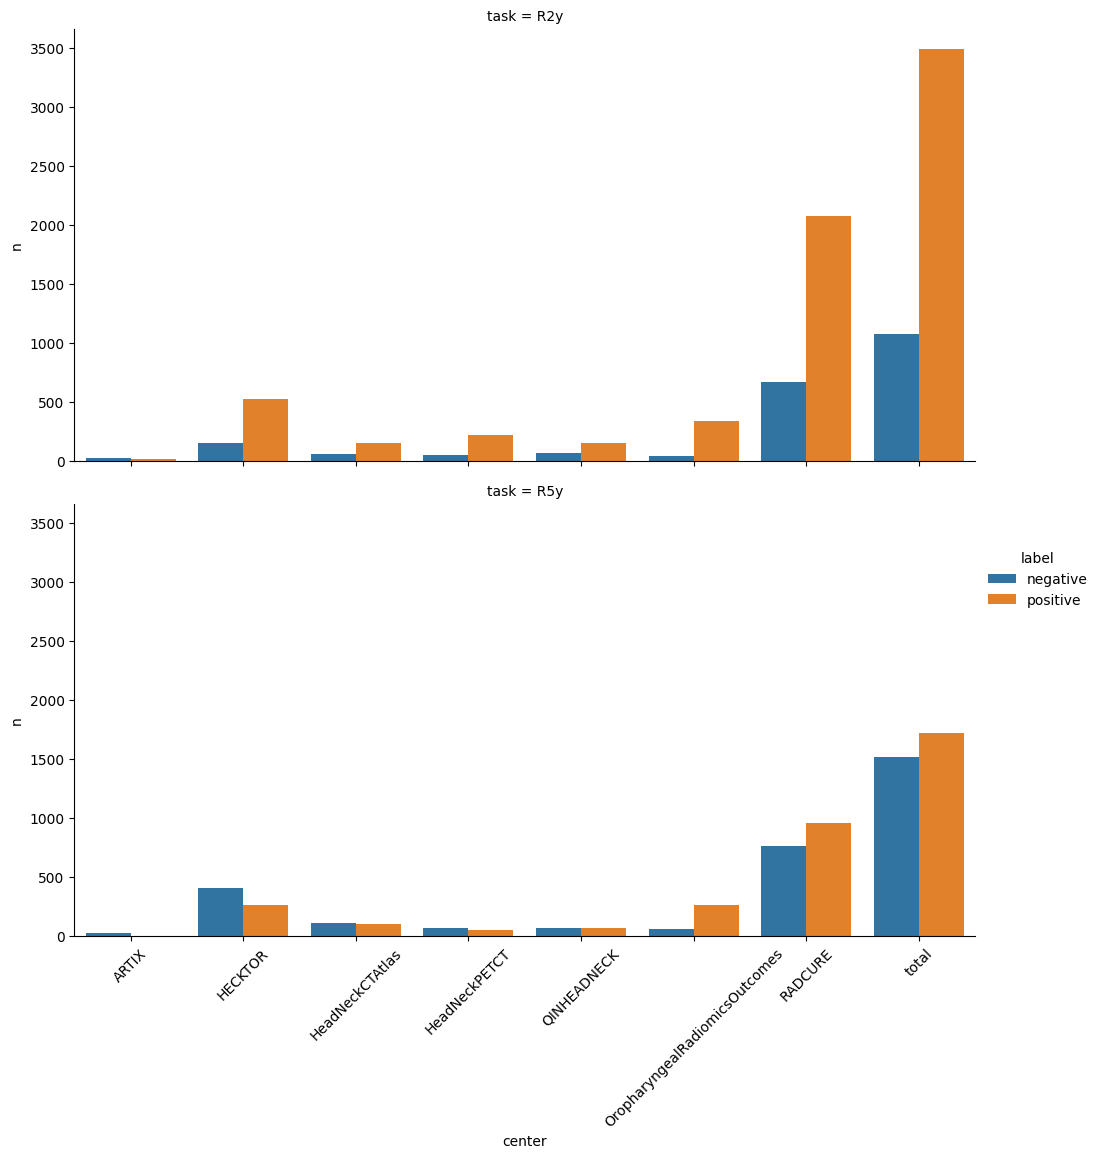

In [4]:
import seaborn as sns
from matplotlib import pyplot as plt
sns.catplot(data=df, kind="bar", x="center", y="n", hue="label", row="task", aspect=2)
plt.xticks(rotation=45)

# features

Oropharyngeal-Radiomics-Outcomes
   MDA

Head-Neck-CT-Atlas
   MDA

QIN-HEADNECK
   UIHC

Head-Neck-PET-CT
   HGJ
   CHUS
   HMR
   CHUM

RADCURE
   UHN

ARTIX
   CEM

HECKTOR
   'CHUM'
   'CHUP'
   'CHUS'
   'HGJ'
   'HMR'
   'MDA'
   'USZ'

## distribution of features across centers

In [4]:
from dataloader import ARTIX, HECKTOR, HeadNeckCTAtlas, HeadNeckPETCT, QINHEADNECK, OropharyngealRadiomicsOutcomes, RADCURE
import pandas
import tqdm

original_center = True
base_path = "./"
features = pandas.DataFrame([])
for name, loader in tqdm.tqdm([("ARTIX", ARTIX), 
                               ("HECKTOR", HECKTOR), 
                               ("HeadNeckCTAtlas", HeadNeckCTAtlas), 
                               ("HeadNeckPETCT", HeadNeckPETCT), 
                               ("QINHEADNECK", QINHEADNECK), 
                               ("OropharyngealRadiomicsOutcomes", OropharyngealRadiomicsOutcomes), 
                               ("RADCURE", RADCURE)], ncols=100):
    loader = loader(None)
    x, y = loader.build_dataset(base_path)
    y = y.set_index("patient")
    if original_center:
        x["center"] = y.loc[x["patient"]]["center"].values
    else:
        x["center"] = name
    features = pandas.concat((features, x))
print(features)

100%|█████████████████████████████████████████████████████████████████| 7/7 [00:26<00:00,  3.77s/it]

         name      value features       patient modality center
0           0  12.017995    ct-fm           098    image    CEM
1           1  27.682295    ct-fm           098    image    CEM
2           2  -9.570662    ct-fm           098    image    CEM
3           3 -18.106740    ct-fm           098    image    CEM
4           4 -15.461066    ct-fm           098    image    CEM
...       ...        ...      ...           ...      ...    ...
2569723   763   1.956697  vista3d  RADCURE-4130    image    UHN
2569724   764   5.753001  vista3d  RADCURE-4130    image    UHN
2569725   765   4.778528  vista3d  RADCURE-4130    image    UHN
2569726   766  14.083810  vista3d  RADCURE-4130    image    UHN
2569727   767  -6.513495  vista3d  RADCURE-4130    image    UHN

[19769216 rows x 6 columns]


In [ ]:
import plotly.express as px
fts = "suprem"
X = features[(features["modality"] == "image") & (features["features"] == fts) & (features["name"] == 0)]
fig = px.histogram(X, x="value", color="center", marginal="box", hover_data=X.columns)
fig.show()

ct-fm


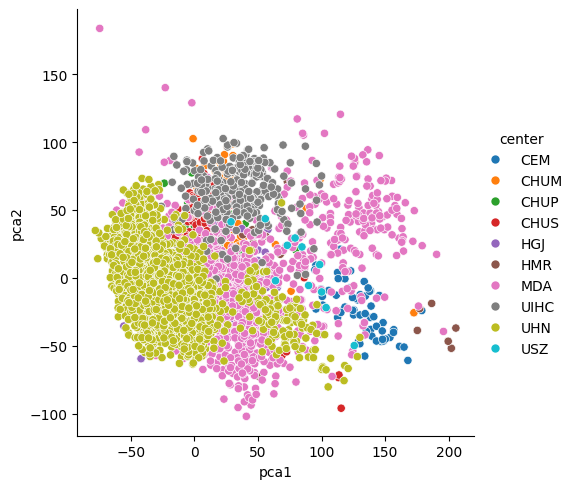

llm-BioBERT-mnli-snli-scinli-scitail-mednli-stsb


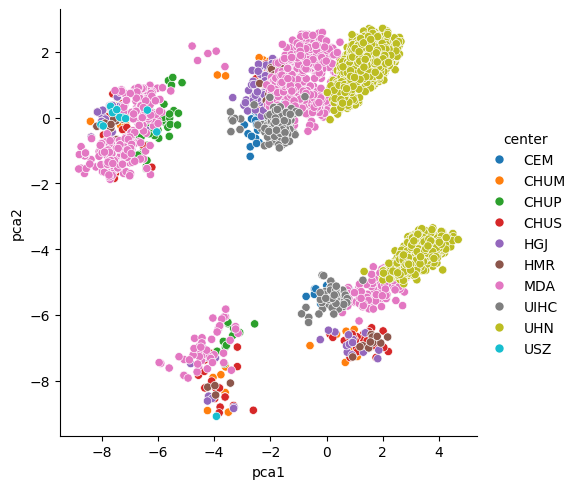

llm-BioLORD-2023-M


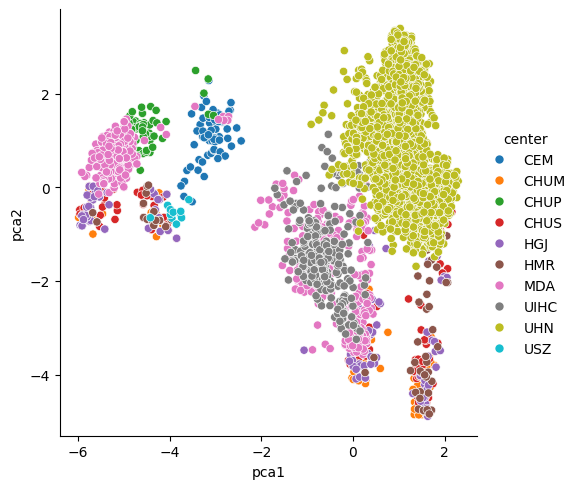

llm-embeddinggemma-300m-medical


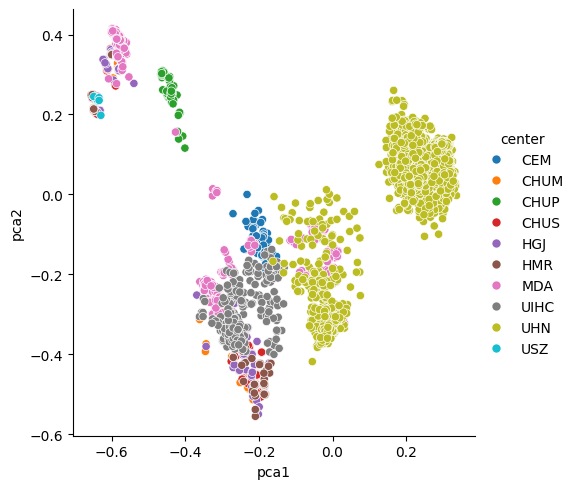

suprem


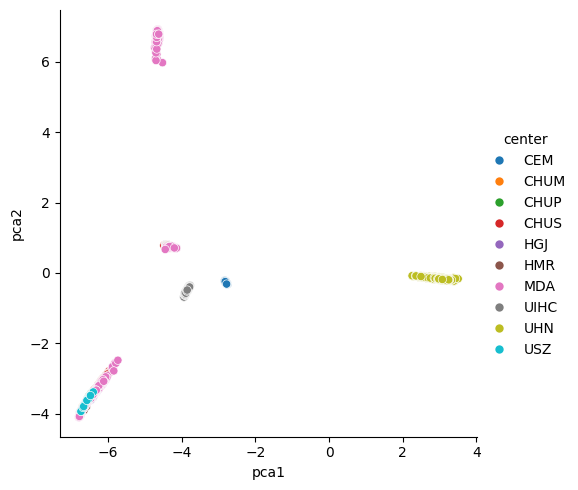

vista3d


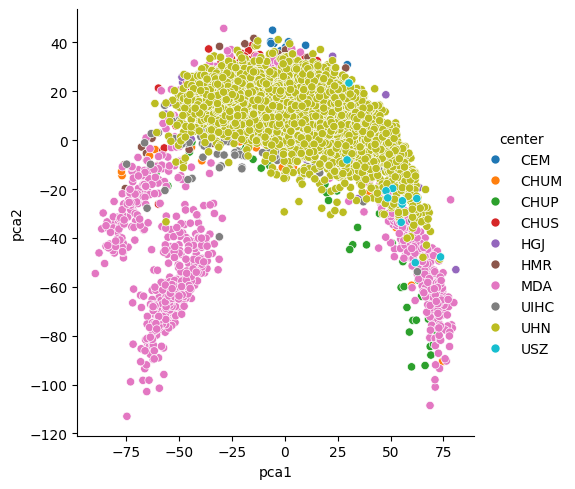

In [5]:
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt

center = features[["patient", "center"]].drop_duplicates().set_index("patient")

# for each FM project to 2 dim with PCA and display by coloring each center (not dataset !!!, e.g., MDA/CHUJ/CHUM/...)
for fts in features["features"].unique():
    print(fts)
    X = features[(features["features"] == fts)]
    X = X.pivot(index="patient", columns=["name"], values="value").sort_index(axis="columns")    
    pca = PCA(n_components=2)
    new_X = pca.fit_transform(X.values)
    df = [{"center": center.loc[X.index[i]]["center"], "pca1": x[0], "pca2": x[1]} for i, x in enumerate(new_X)]
    df = pandas.DataFrame(df)
    sns.relplot(pandas.DataFrame(df), x="pca1", y="pca2", hue="center")
    plt.show()

# KL divergence

In [1]:
import numpy as np
import pandas

def kl(p, q):
    return p * np.log(p/q)

def js(p,q):
    m = (p + q) / 2
    return (kl(p,m) + kl(q,m)) / 2

n = 200
p = np.random.uniform(low=1e-4, high=1, size=n)
q = np.random.uniform(low=1e-4, high=1, size=n)

df = []
for i in p:
    for j in q:
        df.append({"name": "KL(P|Q)", "p": i, "q": j, "kl": kl(i,j)})
        df.append({"name": "KL(Q|P)", "p": i, "q": j, "kl": kl(j,i)})
        df.append({"name": "JS(P|Q)", "p": i, "q": j, "js": js(i,j)})
        df.append({"name": "JS(Q|P)", "p": i, "q": j, "js": js(j,i)})
df = pandas.DataFrame(df)

<Axes: xlabel='q', ylabel='p'>

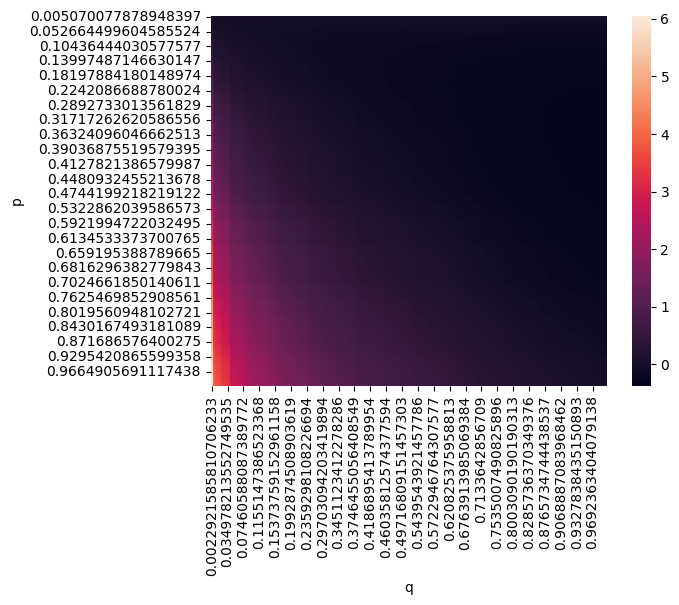

In [2]:
import seaborn as sns

dff = df[df["name"] == "KL(P|Q)"].pivot(index="p", columns="q", values="kl")
sns.heatmap(dff)

<Axes: xlabel='q', ylabel='p'>

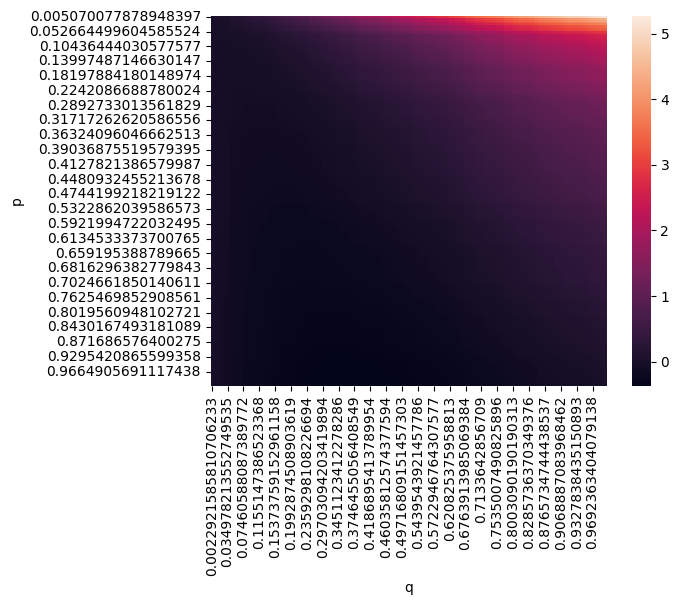

In [3]:
dff = df[df["name"] == "KL(Q|P)"].pivot(index="p", columns="q", values="kl")
sns.heatmap(dff)

<Axes: xlabel='q', ylabel='p'>

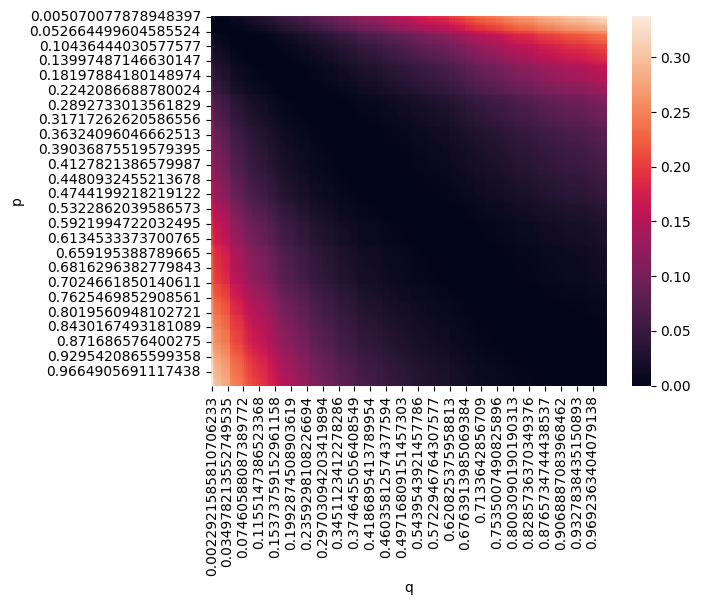

In [4]:
dff = df[df["name"] == "JS(P|Q)"].pivot(index="p", columns="q", values="js")
sns.heatmap(dff)

<Axes: xlabel='q', ylabel='p'>

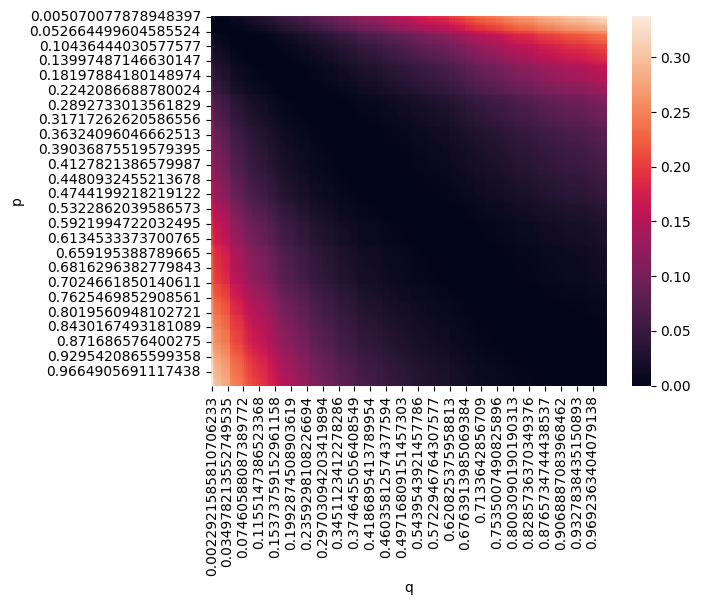

In [5]:
dff = df[df["name"] == "JS(Q|P)"].pivot(index="p", columns="q", values="js")
sns.heatmap(dff)

# test code

In [ ]:
from classifiers.ThreeAxialTransformer import ThreeAxialTransformer

m = ThreeAxialTransformer(dims=(300,300,250), 
                          n_dim=32, 
                          n_layer=3,
                          n_class=1, 
                          pos_embed=False, 
                          pool_kernel_size=2,
                          pool_stride_size=2)

In [ ]:
import torch
device = torch.device("cuda")
print(device)

In [ ]:
m = m.to(device)

In [ ]:
print(m.get_num_params())

In [ ]:
x = [
    {"dataset": "artix", "image": r"E:\bilel\ARTIX\ARTIX\DICOM_ARTIX_data\001\CT0\DOE^JOHN_ANON61841_CT_2017-06-21_100509_ORL.(sauf.sinus)_ORL.2MM_n198__00000"},
    {"dataset": "artix", "image": r"E:\bilel\ARTIX\ARTIX\DICOM_ARTIX_data\004\CT0\DOE^JOHN_ANON17151_CT_2017-03-30_174237_ORL.(sauf.sinus)_ORL.2MM_n211__00000"},
]

o = m(x, device)
print(o.shape)